In [1]:
import matplotlib.pyplot as plt
from pycellga.GraphProblem import GraphRastriginProblem, GraphRosenbrockProblem
from pycellga.mutation.byte_mutation_random import ByteMutationRandom
from pycellga.recombination.byte_one_point_crossover import ByteOnePointCrossover
from pycellga.selection.tournament_selection import TournamentSelection
from pycellga.optimizer import graph_cga
from pycellga.utils import set_up_problem, PROBLEM_TYPING
import numpy as np
import cma
import networkx as nx

from pyswarms.single.global_best import GlobalBestPSO
from scipy.optimize import differential_evolution

from pycellga.GraphProblem import GraphAckleyProblem, GraphGriewankProblem

import pandas as pd
import seaborn as sns

def set_up_problem(n_rows, n_cols, dims, offset, problem_type: PROBLEM_TYPING, boundaries: int = 5, graph_type: str="torus", **kwargs)-> PROBLEM_TYPING:

    n_nodes = n_rows * n_cols

    if graph_type == "torus":
        grid = nx.grid_graph(dim=(n_rows, n_cols), periodic=True)
        node_map = {node: i for i, node in enumerate(grid.nodes)}
        graph = nx.Graph()
        for edge in grid.edges:
            graph.add_edge(node_map[edge[0]], node_map[edge[1]])
    elif graph_type == "erdos_renyi":
        graph = nx.erdos_renyi_graph(n=n_nodes, **kwargs)
    elif graph_type == "watts_strogatz":
        graph = nx.watts_strogatz_graph(n=n_nodes, **kwargs)
    elif graph_type == "barabasi_albert":
        graph = nx.barabasi_albert_graph(n=n_nodes, **kwargs )
    else:
        raise ValueError(f"Unknown graph_type: {graph_type}")

    return problem_type(n_var=dims, graph=graph, offset=offset, boundaries=boundaries)

def run_cga(dims, n_generations, n_rows, n_cols, problem):
    result = graph_cga(
        n_rows=n_rows,
        n_cols=n_cols,
        n_gen=n_generations,
        ch_size=dims,
        p_crossover=0.9,
        p_mutation=0.2,
        problem=problem,
        selection=TournamentSelection,
        recombination=ByteOnePointCrossover,
        mutation=ByteMutationRandom,
        seed_par=100,

    )
    return (result.chromosome, result.fitness_value, result.fitness_history)



def run_cma(problem, dims, max_evals, boundaries, generation_size=20):
    x0 = np.random.random(dims)
    sigma = 0.5
    fitness_history = []

    best_so_far = float('inf')
    es = cma.CMAEvolutionStrategy(
        x0,
        sigma,
        {
            'maxfeval': max_evals,
            'popsize': generation_size,
            'verb_disp': 0,
            'bounds': [[-boundaries] * dims, [boundaries] * dims],
        }
    )
    eval_count = 0
    while not es.stop() and eval_count < max_evals:
        solutions = es.ask()
        function_values = [problem.f(x) for x in solutions]

        for val in function_values:
            if val < best_so_far:
                best_so_far = val
            fitness_history.append(best_so_far)

        eval_count += len(function_values)
        es.tell(solutions, function_values)

    return (es.result.xbest, es.result.fbest, fitness_history)


def run_pso(problem, dims, max_evals, boundaries, generation_size=30):
    options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

    bounds = (np.full(dims, -boundaries), np.full(dims, boundaries))

    def objective_function(X):
        return np.array([problem.f(x) for x in X])

    optimizer = GlobalBestPSO(
        n_particles=generation_size,
        dimensions=dims,
        options=options,
        bounds=bounds
    )

    iters = max_evals // generation_size
    best_cost, best_pos = optimizer.optimize(objective_function, iters=iters)

    fitness_history = []
    for cost in optimizer.cost_history:
        fitness_history.extend([cost] * generation_size)

    return (best_pos, best_cost, fitness_history)

def run_differential_evolution(problem, dims, max_evals, boundaries, generation_size=15):
    bounds = [(-boundaries, boundaries) for _ in range(dims)]

    eval_count = 0
    best_fitness_so_far = float('inf')
    fitness_history = []

    def objective_with_tracking(x):
        nonlocal eval_count, best_fitness_so_far, fitness_history

        eval_count += 1
        if eval_count > max_evals:
            return float('inf')

        fitness = problem.f(x)

        if fitness < best_fitness_so_far:
            best_fitness_so_far = fitness

        fitness_history.append(best_fitness_so_far)

        return fitness

    fitness_history = []

    result = differential_evolution(
        objective_with_tracking,
        bounds=bounds,
        popsize=generation_size,
        maxiter=max_evals // generation_size,
        seed=42,
        disp=False,
    )

    return result.x, result.fun, fitness_history

In [2]:
def study_erdos_renyi(p_values, problem_classes, dims, n_generations, repetitions=5, n_rows=5, n_cols=5, boundaries=5, **kwargs):
    results = {}
    for problem_class in problem_classes:
        class_results = {}
        for p in p_values:
            fitness_values = []
            for _ in range(repetitions):
                problem = set_up_problem(
                    n_rows=n_rows, n_cols=n_cols, dims=dims,
                    offset=np.random.rand() * np.random.randint(1, boundaries) * (-1) ** np.random.randint(0, 2),
                    problem_type=problem_class,
                    boundaries=boundaries,
                    graph_type="erdos_renyi",
                    p=p
                )
                _, fitness_value, _ = run_cga(
                    problem=problem, dims=dims,
                    n_generations=n_generations,
                    n_rows=n_rows, n_cols=n_cols
                )
                fitness_values.append(fitness_value)
            class_results[f"p={p}"] = fitness_values
        results[problem_class.__name__] = class_results
    return results

def study_watts_strogatz(k_values, p_values, problem_classes, dims, n_generations, repetitions=5, n_rows=5, n_cols=5, boundaries=5,**kwargs):
    results = {}
    for problem_class in problem_classes:
        class_results = {}
        for k in k_values:
            for p in p_values:
                fitness_values = []
                for _ in range(repetitions):
                    problem = set_up_problem(
                        n_rows=n_rows, n_cols=n_cols, dims=dims,
                        offset=np.random.rand() * np.random.randint(1, boundaries) * (-1) ** np.random.randint(0, 2),
                        problem_type=problem_class,
                        boundaries=boundaries,
                        graph_type="watts_strogatz",
                        k=k, p=p
                    )
                    _, fitness_value, _ = run_cga(
                        problem=problem, dims=dims,
                        n_generations=n_generations,
                        n_rows=n_rows, n_cols=n_cols
                    )
                    fitness_values.append(fitness_value)
                class_results[(k, p)] = fitness_values
        results[problem_class.__name__] = class_results
    return results

def study_barabasi_albert(m_values, problem_classes, dims, n_generations, repetitions=5, n_rows=5, n_cols=5, boundaries=5, **kwargs):
    results = {}
    for problem_class in problem_classes:
        class_results = {}
        for m in m_values:
            label = f"m={m}"
            fitness_values = []
            for _ in range(repetitions):
                problem = set_up_problem(
                    n_rows=n_rows, n_cols=n_cols, dims=dims,
                    offset=np.random.rand() * np.random.randint(1, boundaries) * (-1) ** np.random.randint(0, 2),
                    problem_type=problem_class,
                    boundaries=boundaries,
                    graph_type="barabasi_albert",
                    m=m
                )
                _, fitness_value, _ = run_cga(
                    problem=problem, dims=dims,
                    n_generations=n_generations,
                    n_rows=n_rows, n_cols=n_cols
                )
                fitness_values.append(fitness_value)
            class_results[label] = fitness_values
        results[problem_class.__name__] = class_results
    return results

def plot_param_bar(results, title_prefix):
    for problem_name, result_dict in results.items():
        keys = list(result_dict.keys())
        means = [np.mean(result_dict[k]) for k in keys]
        stds = [np.std(result_dict[k]) for k in keys]

        plt.figure(figsize=(10, 5))
        bars = plt.bar(keys, means, yerr=stds, capsize=5, color='skyblue')
        plt.ylabel("Fitness")
        plt.title(f"{title_prefix} - {problem_name}")
        plt.grid(axis='y')

        for bar, mean in zip(bars, means):
            plt.text(bar.get_x() + bar.get_width()/2.0, mean + 0.01, f"{mean:.2f}", ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

def plot_param_heatmap(results, title_prefix):
    for problem_name, result_dict in results.items():
        data = []
        for (k_val, p_val), value in result_dict.items():
            fitness_value = np.mean(value)
            data.append((k_val, p_val, fitness_value))

        df = pd.DataFrame(data, columns=['k', 'p', 'fitness'])
        pivot_df = df.pivot(index='p', columns='k', values='fitness')

        plt.figure(figsize=(16, 8))
        sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Fitness'})
        plt.title(f"{title_prefix} - {problem_name}")
        plt.xlabel("k")
        plt.ylabel("p")
        plt.tight_layout()
        plt.show()


config = {
    'dims': 50,
    'n_generations': 100,
    'n_rows': 5,
    'n_cols': 5,
    'boundaries': 5,
}

problem_classes = [
    GraphRastriginProblem,
    GraphRosenbrockProblem,
    GraphAckleyProblem,
    GraphGriewankProblem
]


erdos_results = study_erdos_renyi(p_values=[0.1, 0.3, 0.5, 0.7, 0.9], problem_classes=problem_classes, repetitions=10,  **config)

watts_results = study_watts_strogatz(k_values=list(range(2, config['n_rows']*config['n_cols'], 2)), p_values=[0.1, 0.3, 0.5, 0.7, 0.9], problem_classes=problem_classes, repetitions=10, **config)

barabasi_results = study_barabasi_albert(m_values=list(range(2, config['n_rows']*config['n_cols'], 2)), problem_classes=problem_classes, repetitions=10, **config)


/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:36: RuntimeWarning: overflow encountered in square
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:36: RuntimeWarning: overflow encountered in multiply
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:36: RuntimeWarning: invalid value encountered in cos
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:33: RuntimeWarning: overflow encountered in scalar multiply
  10
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:36: RuntimeWarning: invalid value encountered in subtract
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))


[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individual 12 has no neighbors. Using self-mating.
[WARN] Individ

/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:61: RuntimeWarning: overflow encountered in power
  (100 * np.power((x[i + 1] - np.power(x[i], 2)), 2)) + np.power((1 - x[i]), 2)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:61: RuntimeWarning: overflow encountered in scalar multiply
  (100 * np.power((x[i + 1] - np.power(x[i], 2)), 2)) + np.power((1 - x[i]), 2)


[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individual 20 has no neighbors. Using self-mating.
[WARN] Individ

/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:56: RuntimeWarning: invalid value encountered in subtract
  x = x - self.offset


...

/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:86: RuntimeWarning: overflow encountered in scalar power
  sum1 = sum(gene ** 2 for gene in x)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:87: RuntimeWarning: overflow encountered in scalar multiply
  sum2 = sum(np.cos(2 * np.pi * gene) for gene in x)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:87: RuntimeWarning: invalid value encountered in cos
  sum2 = sum(np.cos(2 * np.pi * gene) for gene in x)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:84: RuntimeWarning: invalid value encountered in subtract
  x = x - self.offset


[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neighbors. Using self-mating.
[WARN] Individual 4 has no neig

/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:113: RuntimeWarning: overflow encountered in scalar power
  sum_sq = sum(xi**2 for xi in x)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:112: RuntimeWarning: invalid value encountered in subtract
  x = x - self.offset


[WARN] Individual 8 has no neighbors. Using self-mating.
[WARN] Individual 23 has no neighbors. Using self-mating.
[WARN] Individual 8 has no neighbors. Using self-mating.
[WARN] Individual 23 has no neighbors. Using self-mating.
[WARN] Individual 8 has no neighbors. Using self-mating.
[WARN] Individual 23 has no neighbors. Using self-mating.
[WARN] Individual 8 has no neighbors. Using self-mating.
[WARN] Individual 23 has no neighbors. Using self-mating.
[WARN] Individual 8 has no neighbors. Using self-mating.
[WARN] Individual 23 has no neighbors. Using self-mating.
[WARN] Individual 8 has no neighbors. Using self-mating.
[WARN] Individual 23 has no neighbors. Using self-mating.
[WARN] Individual 8 has no neighbors. Using self-mating.
[WARN] Individual 23 has no neighbors. Using self-mating.
[WARN] Individual 8 has no neighbors. Using self-mating.
[WARN] Individual 23 has no neighbors. Using self-mating.
[WARN] Individual 8 has no neighbors. Using self-mating.
[WARN] Individual 23 ha

/home/wladek/IdeaProjects/pycellga/venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:86: RuntimeWarning: overflow encountered in scalar add
  sum1 = sum(gene ** 2 for gene in x)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:113: RuntimeWarning: overflow encountered in scalar add
  sum_sq = sum(xi**2 for xi in x)


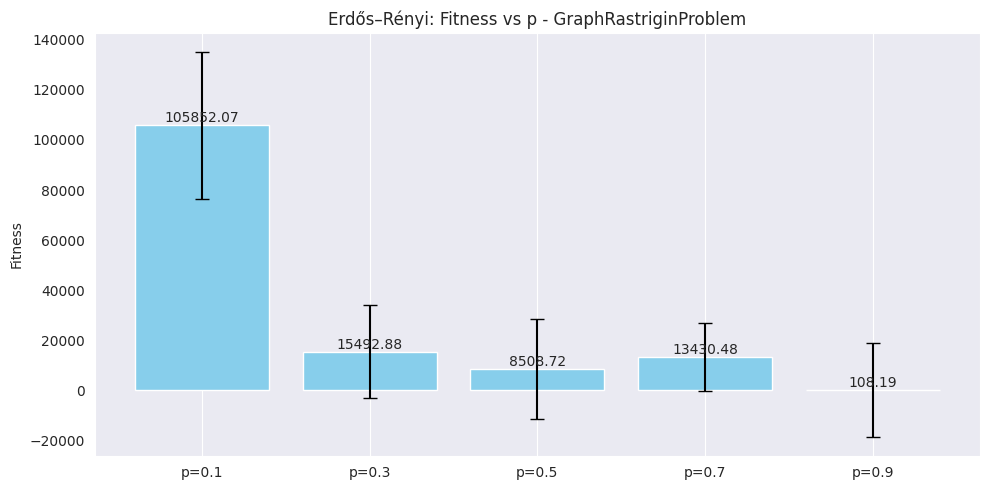

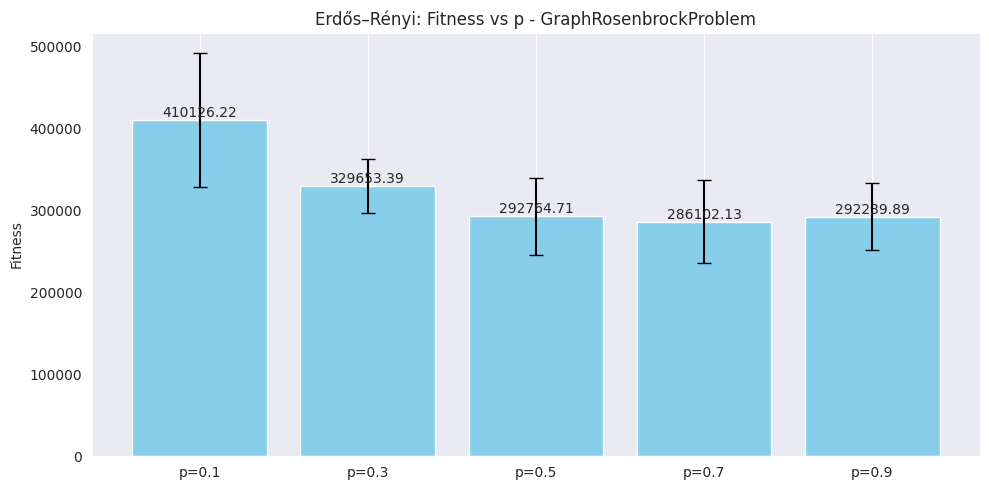

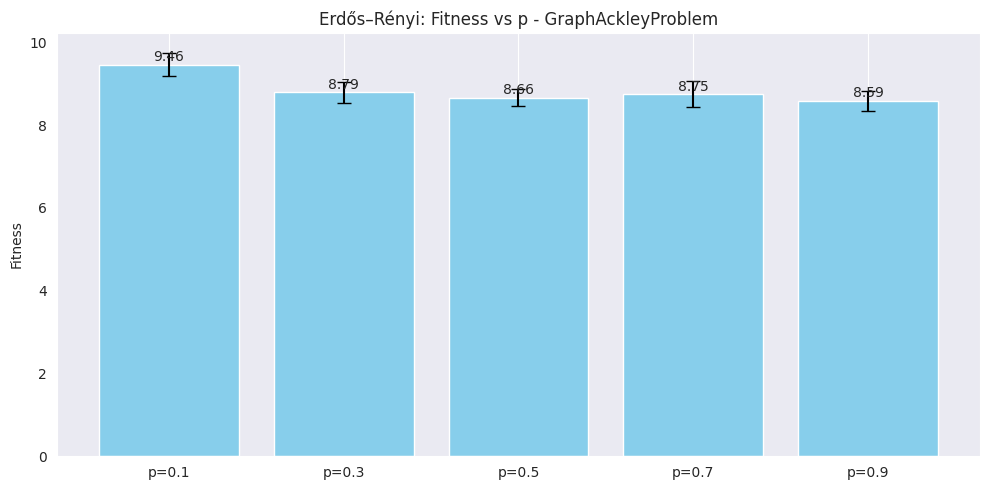

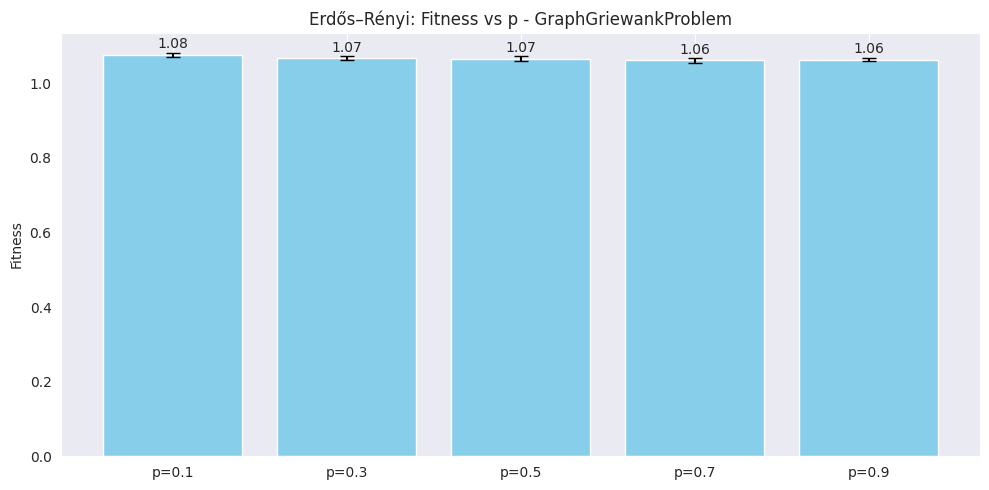

In [3]:
plot_param_bar(erdos_results, "Erdős–Rényi: Fitness vs p")

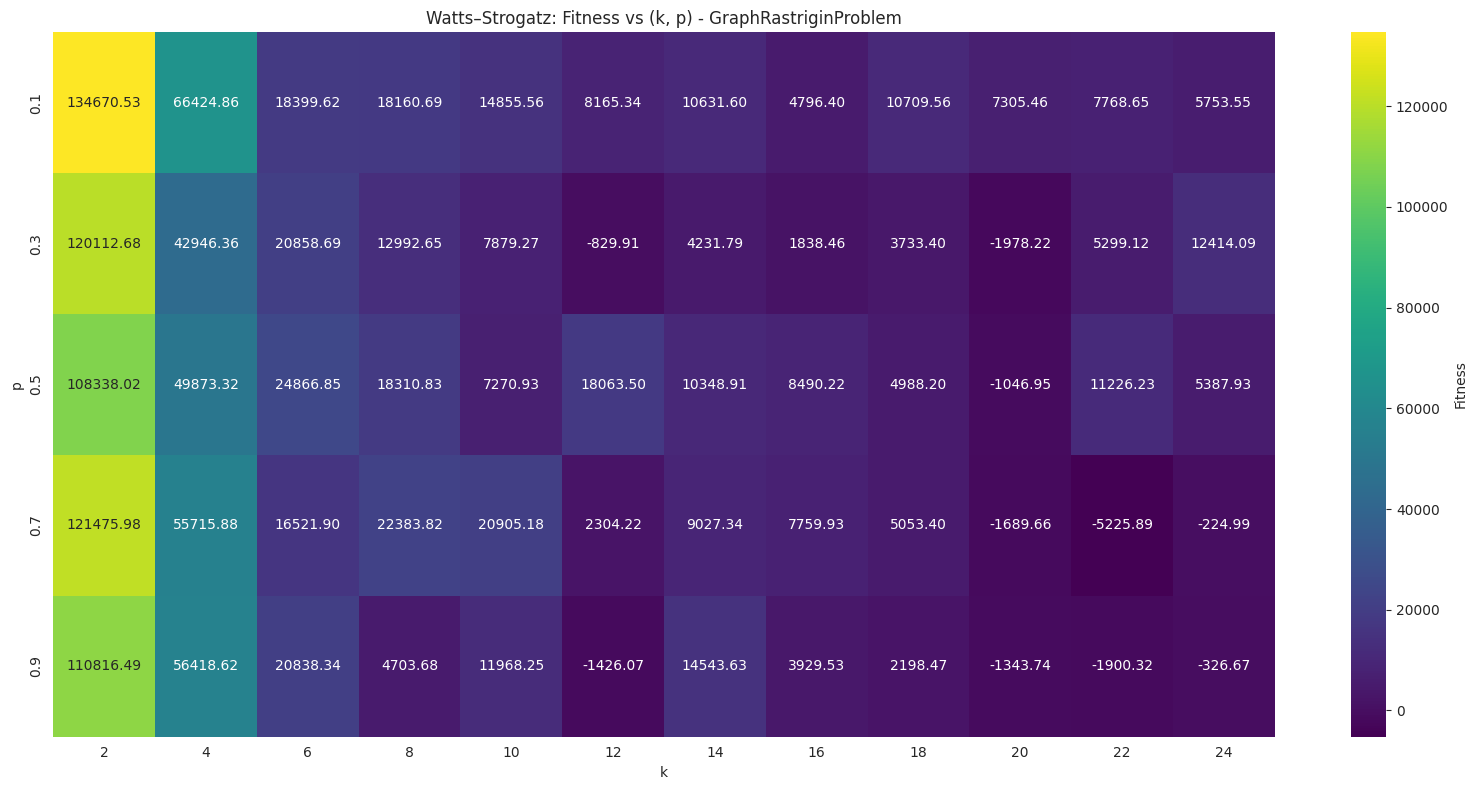

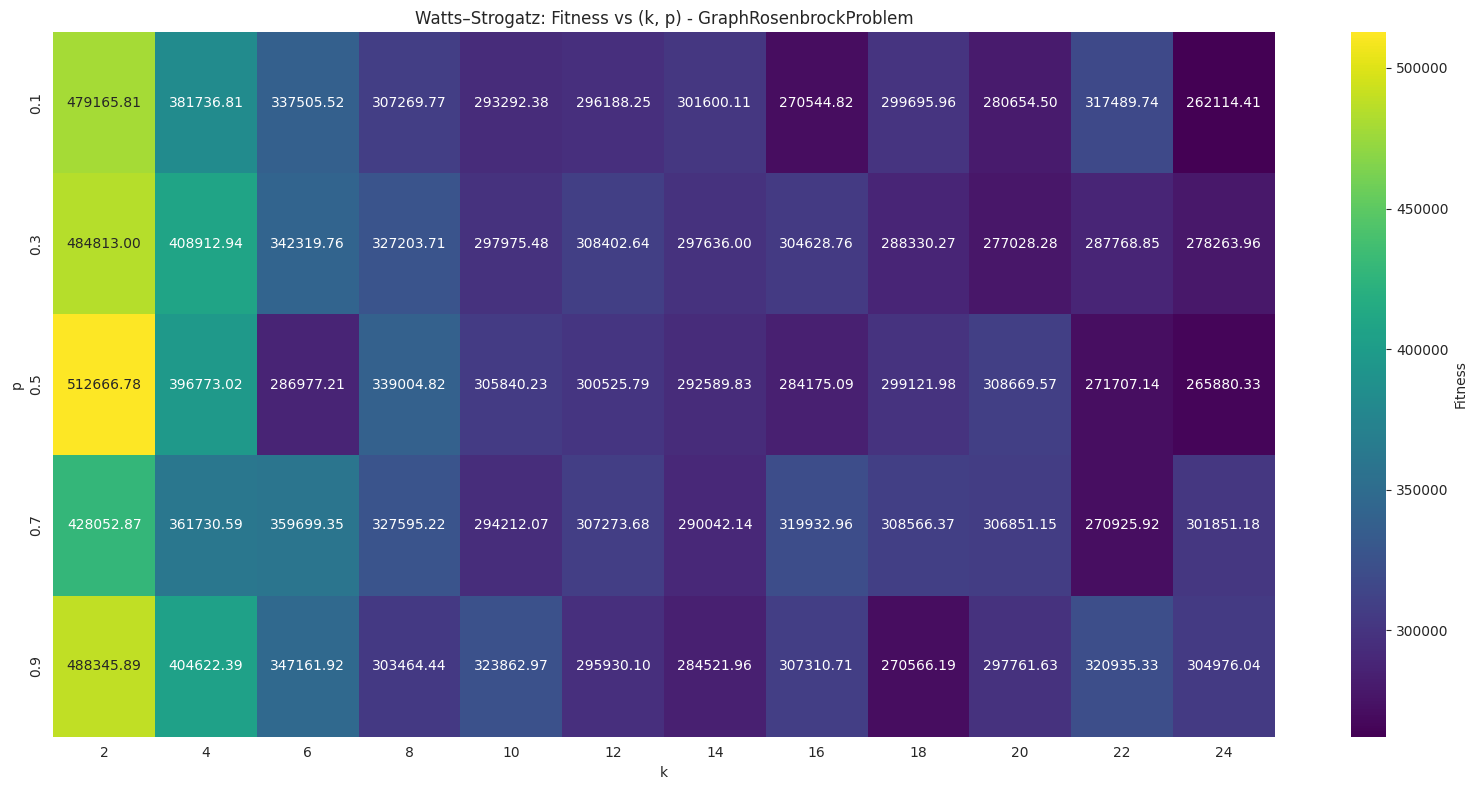

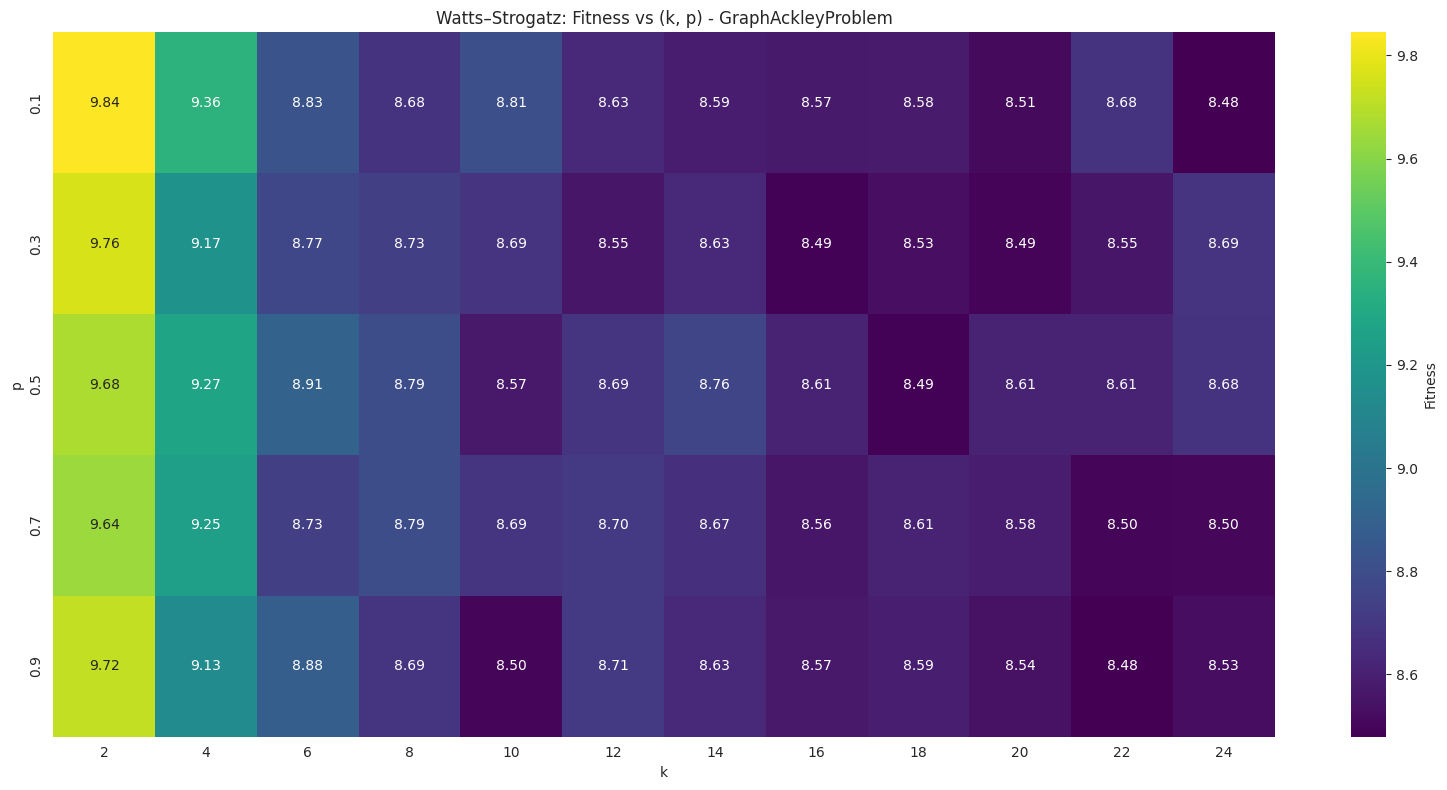

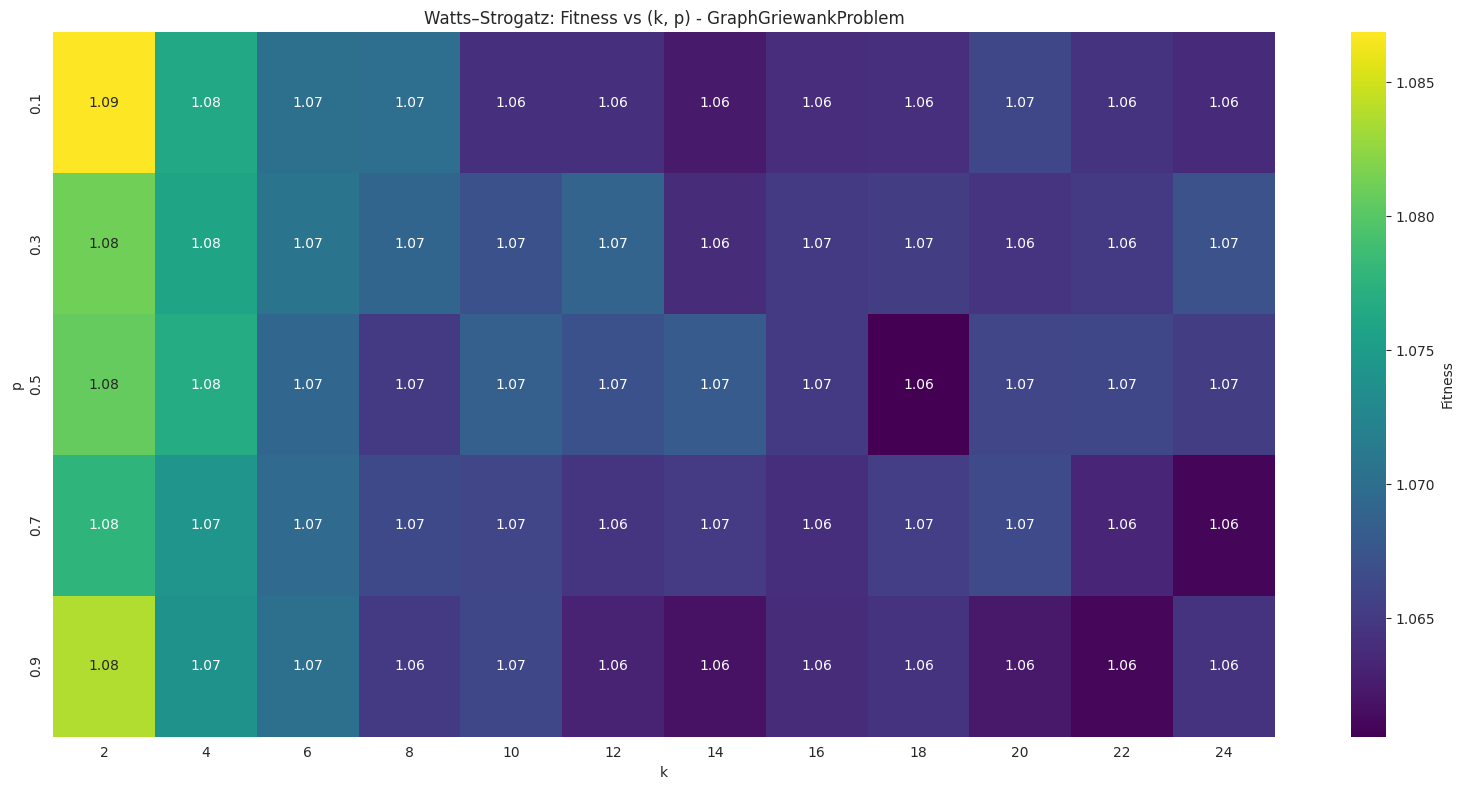

In [4]:
plot_param_heatmap(watts_results, "Watts–Strogatz: Fitness vs (k, p)")

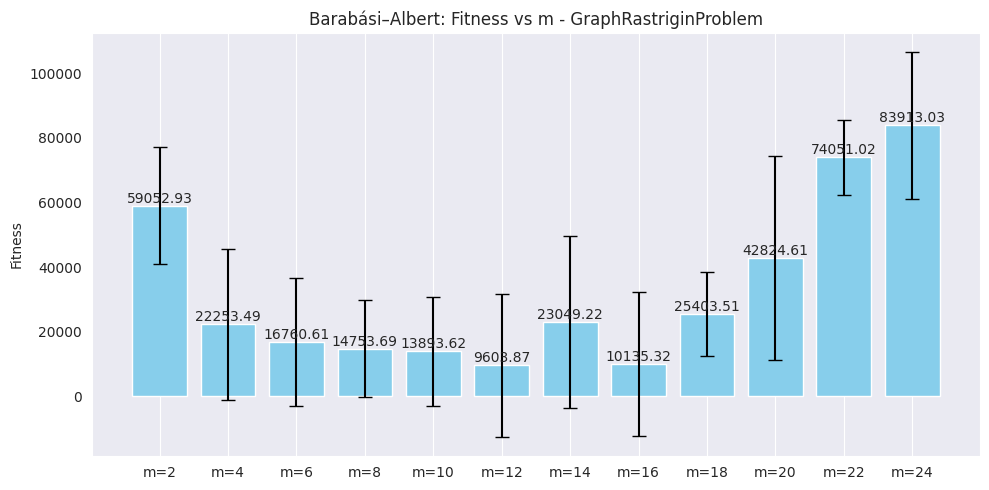

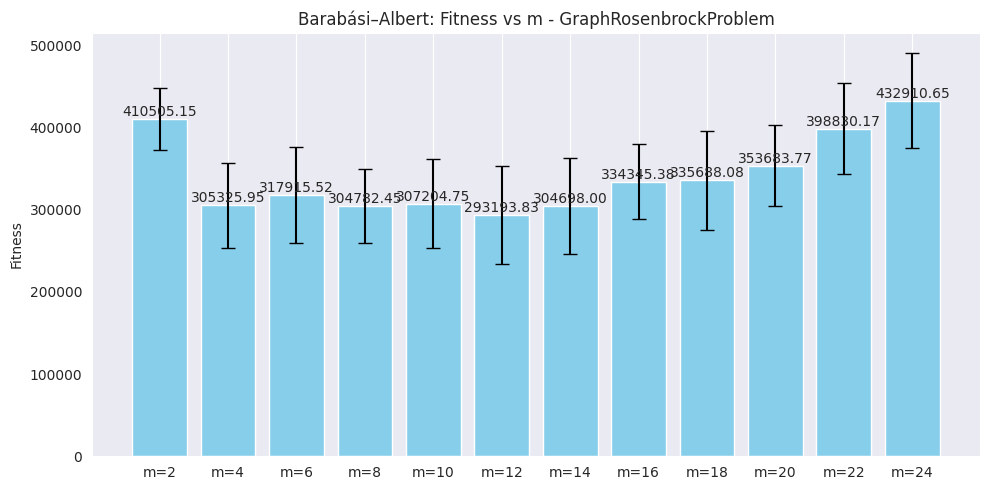

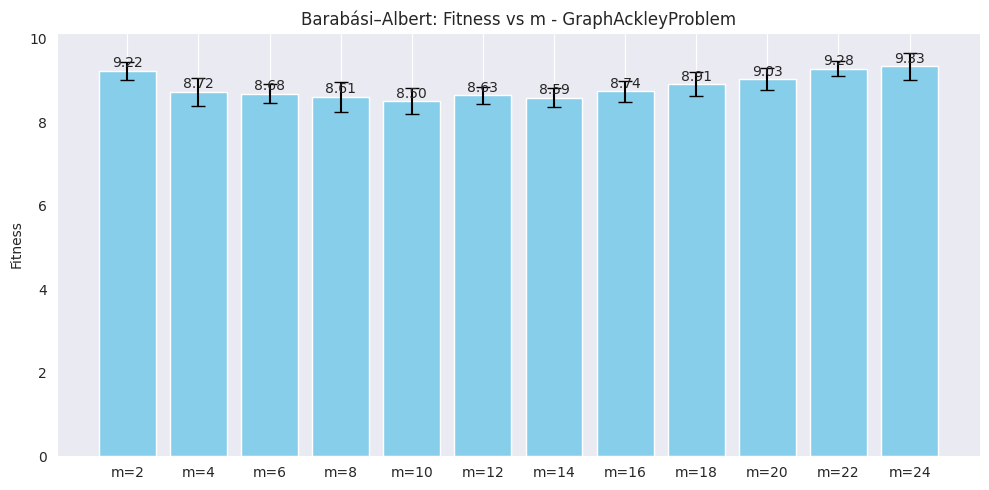

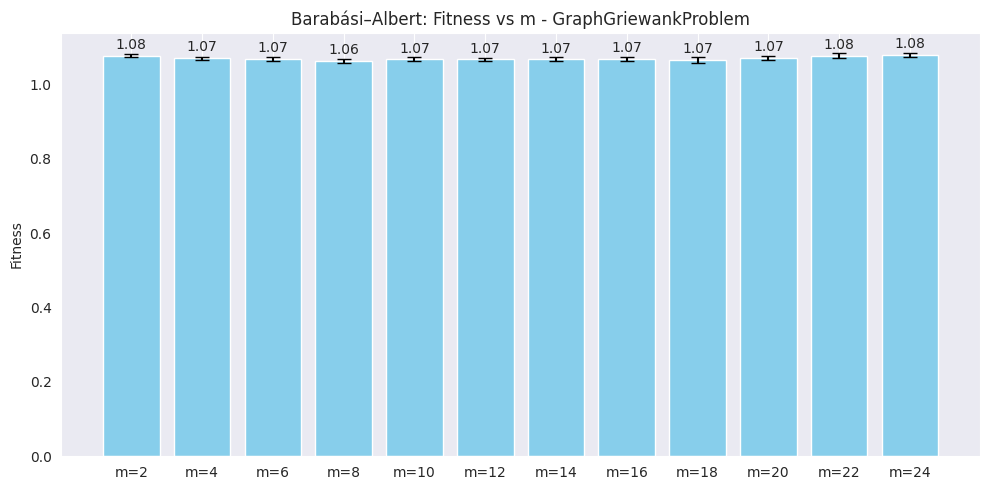

In [5]:
plot_param_bar(barabasi_results, "Barabási–Albert: Fitness vs m")

In [6]:
def evaluate_method(method_func, problem_type, dims, max_evals, repetitions=10, use_cga=False, graph_type="torus",  n_rows=5, n_cols=5, boundaries=5, label=None, **kwargs):
    histories = []

    for _ in range(repetitions):
        problem = set_up_problem(
            n_rows=n_rows,
            n_cols=n_cols,
            dims=dims,
            offset=np.random.rand() * np.random.randint(1, boundaries) * (-1) ** np.random.randint(0, 2),
            problem_type=problem_type,
            boundaries=boundaries,
            graph_type=graph_type,
            **kwargs.get('graph_params', {})
        )

        if use_cga:
            result = method_func(
                dims=dims,
                n_generations=max_evals // (2*n_rows*n_cols),
                n_rows=n_rows,
                n_cols=n_cols,
                problem=problem
            )
        else:
            result = method_func(
                problem=problem,
                dims=dims,
                max_evals=max_evals,
                boundaries=boundaries
            )

        histories.append(np.array(result[2]))

    avg_history = np.mean(histories, axis=0)
    std_history = np.std(histories, axis=0)
    return avg_history, std_history

def plot_evaluation_histories(results, title, dims, show_std=False):
    plt.figure(figsize=(14, 7))

    def plot_fitness(avg, std, label, color, show_std=False):
        x = np.arange(len(avg))
        plt.plot(x, avg, label=label, color=color)
        if show_std:
            plt.fill_between(x, avg - std, avg + std, alpha=0.2, color=color)

    for label, (avg, std, color) in results.items():
        plot_fitness(avg, std, label, color, show_std)

    plt.title(f"{title} Problem Dims: {dims}")
    plt.xlabel("Evaluations")
    plt.ylabel("Fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
def run_graph_comparison(problem_classes, graph_types, graphs_params, dims, max_evals, repetitions=10, n_rows=5, n_cols=5, boundaries=5, show_std=False):

    for problem_name, problem_cls in problem_classes.items():
        print(f"Running graph comparison: {problem_name}")
        results = {}

        for graph_type, color in graph_types.items():
            try:
                avg, std = evaluate_method(
                    run_cga,
                    problem_type=problem_cls,
                    use_cga=True,
                    graph_type=graph_type,
                    repetitions= repetitions,
                    n_rows=n_rows,
                    n_cols=n_cols,
                    dims=dims,
                    boundaries=boundaries,
                    max_evals=max_evals,
                    graph_params=graphs_params.get(graph_type, {}),
                )
                results[graph_type] = (avg, std, color)
            except Exception as e:
                print(f"Failed for {graph_type}: {e}")
                continue

        plot_evaluation_histories(results, f"Graph Comparison - {problem_name}", dims, show_std)

def run_size_comparison(problem_classes, grid_configs, graph_type, max_evals,  dims,repetitions=10, boundaries=5, graph_params={}, show_std=False):

    for problem_name, problem_cls in problem_classes.items():
        print(f"Running size comparison: {problem_name}")
        results = {}

        for (n_rows, n_cols), color in grid_configs.items():
            label = f"{n_rows}x{n_cols}"
            try:
                avg, std = evaluate_method(
                    run_cga,
                    problem_type=problem_cls,
                    use_cga=True,
                    graph_type=graph_type,
                    repetitions= repetitions,
                    n_rows=n_rows,
                    n_cols=n_cols,
                    dims=dims,
                    boundaries=boundaries,
                    max_evals=max_evals,
                    graph_params=graph_params
                )
                results[label] = (avg, std, color)
            except Exception as e:
                print(f"Failed for size {label}: {e}")
                continue

        plot_evaluation_histories(results, f"Size Comparison - {problem_name}", dims, show_std)


def run_method_comparison(problem_classes, methods, graph_type, dims, max_evals, repetitions=10, n_rows=5, n_cols=5, boundaries=5, graph_params={}, show_std=False):
    for problem_name, problem_cls in problem_classes.items():
        print(f"Running method comparison: {problem_name}")
        results = {}

        for label, (method, color) in methods.items():
            try:
                avg, std = evaluate_method(
                    method,
                    problem_type=problem_cls,
                    use_cga=(label == "CGA"),
                    graph_type=graph_type,
                    repetitions=repetitions,
                    n_rows=n_rows,
                    n_cols=n_cols,
                    dims=dims,
                    boundaries=boundaries,
                    max_evals=max_evals,
                    graph_params=graph_params
                )
                results[label] = (avg, std, color)
            except Exception as e:
                print(f"Failed for method {label}: {e}")
                continue

        plot_evaluation_histories(results, f"Method Comparison - {problem_name}", dims, show_std)


Running graph comparison: Rastrigin Problem


/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:36: RuntimeWarning: overflow encountered in square
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:36: RuntimeWarning: overflow encountered in multiply
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:36: RuntimeWarning: invalid value encountered in cos
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:36: RuntimeWarning: invalid value encountered in subtract
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:33: RuntimeWarning: overflow encountered in scalar multiply
  10


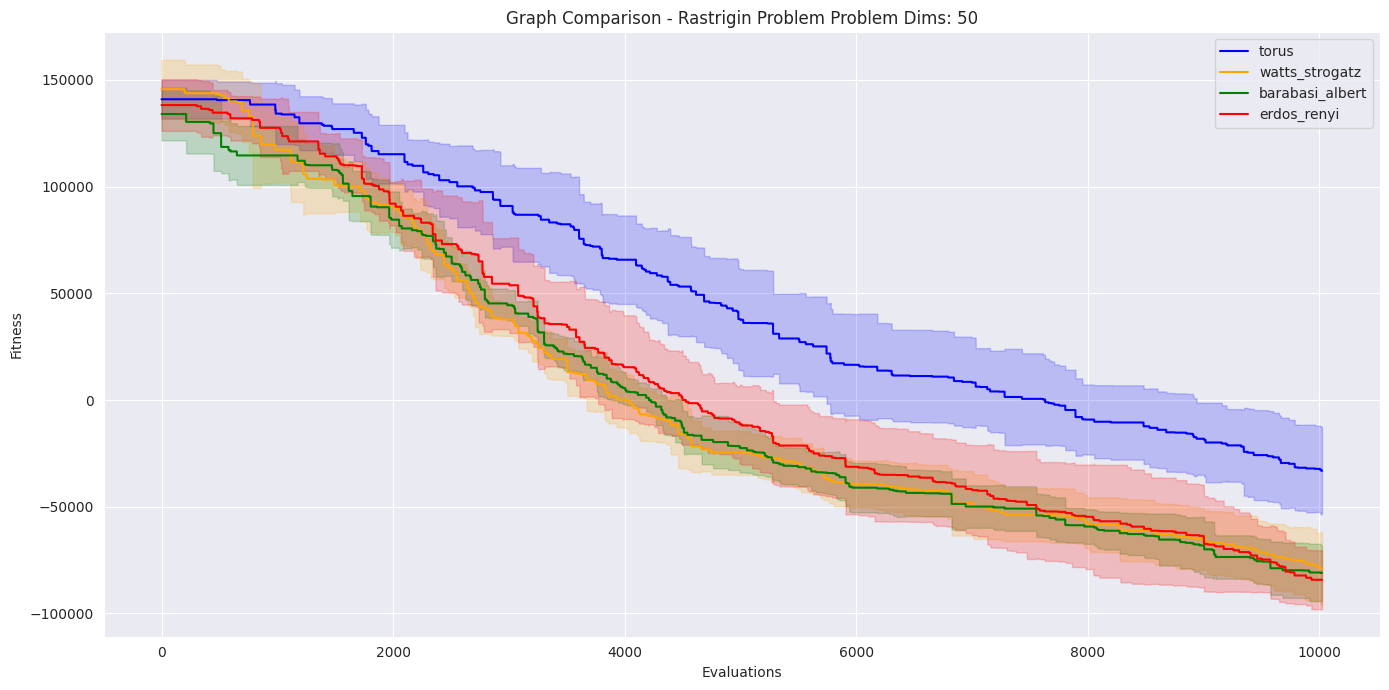

Running graph comparison: Rosenbrock Problem


/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:61: RuntimeWarning: overflow encountered in power
  (100 * np.power((x[i + 1] - np.power(x[i], 2)), 2)) + np.power((1 - x[i]), 2)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:56: RuntimeWarning: invalid value encountered in subtract
  x = x - self.offset
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:61: RuntimeWarning: overflow encountered in scalar multiply
  (100 * np.power((x[i + 1] - np.power(x[i], 2)), 2)) + np.power((1 - x[i]), 2)


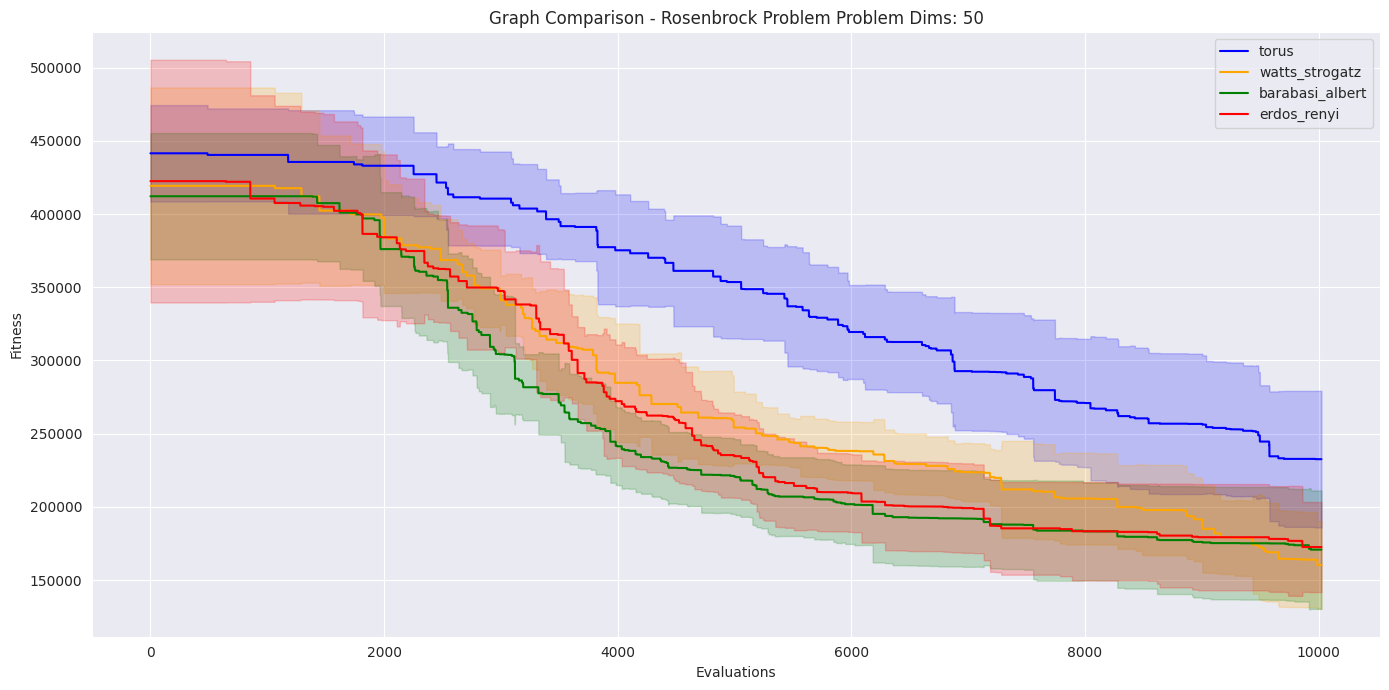

Running graph comparison: Ackley Problem


/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:86: RuntimeWarning: overflow encountered in scalar power
  sum1 = sum(gene ** 2 for gene in x)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:87: RuntimeWarning: overflow encountered in scalar multiply
  sum2 = sum(np.cos(2 * np.pi * gene) for gene in x)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:87: RuntimeWarning: invalid value encountered in cos
  sum2 = sum(np.cos(2 * np.pi * gene) for gene in x)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:84: RuntimeWarning: invalid value encountered in subtract
  x = x - self.offset


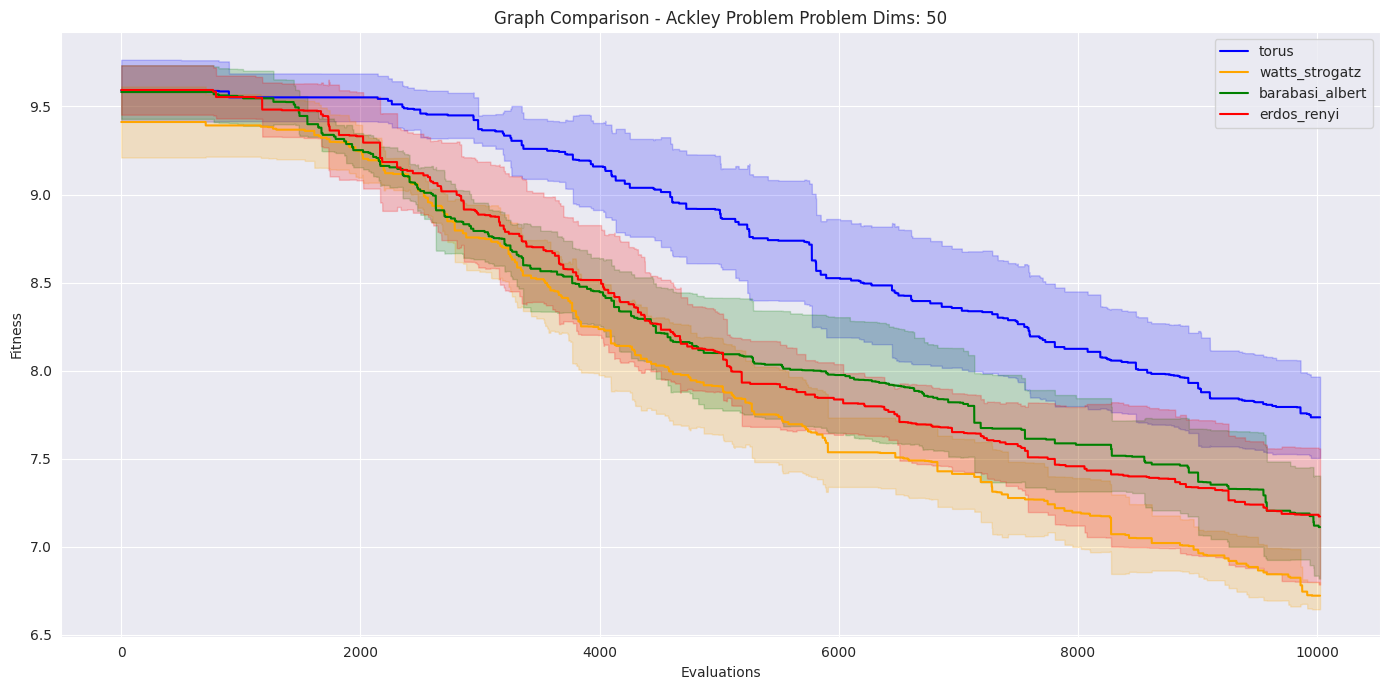

Running graph comparison: Griewank Problem


/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:113: RuntimeWarning: overflow encountered in scalar power
  sum_sq = sum(xi**2 for xi in x)
/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:112: RuntimeWarning: invalid value encountered in subtract
  x = x - self.offset


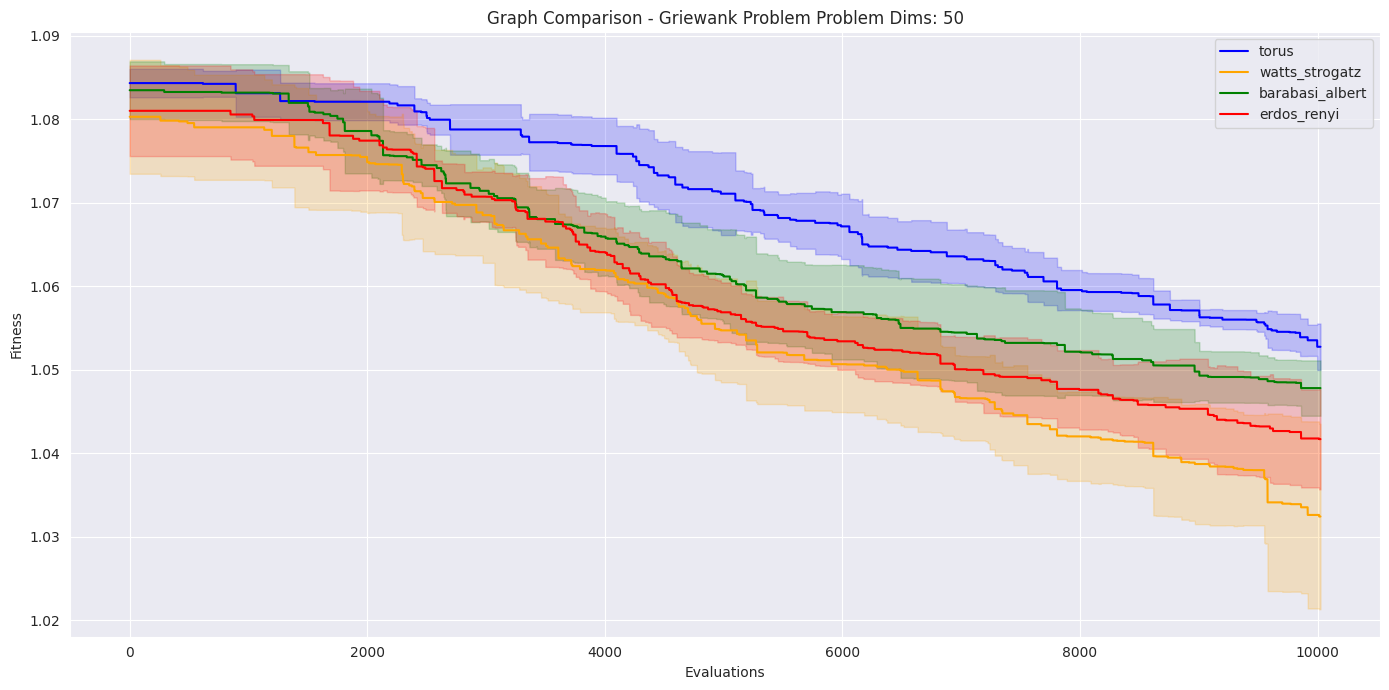

In [8]:

problem_classes = {
    "Rastrigin Problem": GraphRastriginProblem,
    "Rosenbrock Problem": GraphRosenbrockProblem,
    "Ackley Problem": GraphAckleyProblem,
    "Griewank Problem": GraphGriewankProblem,

}

graph_types = {
    "torus": "blue",
    "watts_strogatz": "orange",
    "barabasi_albert": "green",
    "erdos_renyi": "red"
}

graphs_params = {
    "watts_strogatz": {"k": 18, "p": 0.1},
    "barabasi_albert": {"m": 14},
    "erdos_renyi": {"p": 0.5}
}

config = {
    'n_rows': 5,
    'n_cols': 5,
    'boundaries': 5,
}

run_graph_comparison(problem_classes, graph_types, graphs_params, dims=50, max_evals=10000, repetitions=5, show_std=True, **config)


Running size comparison: Rastrigin Problem


/home/wladek/IdeaProjects/pycellga/venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


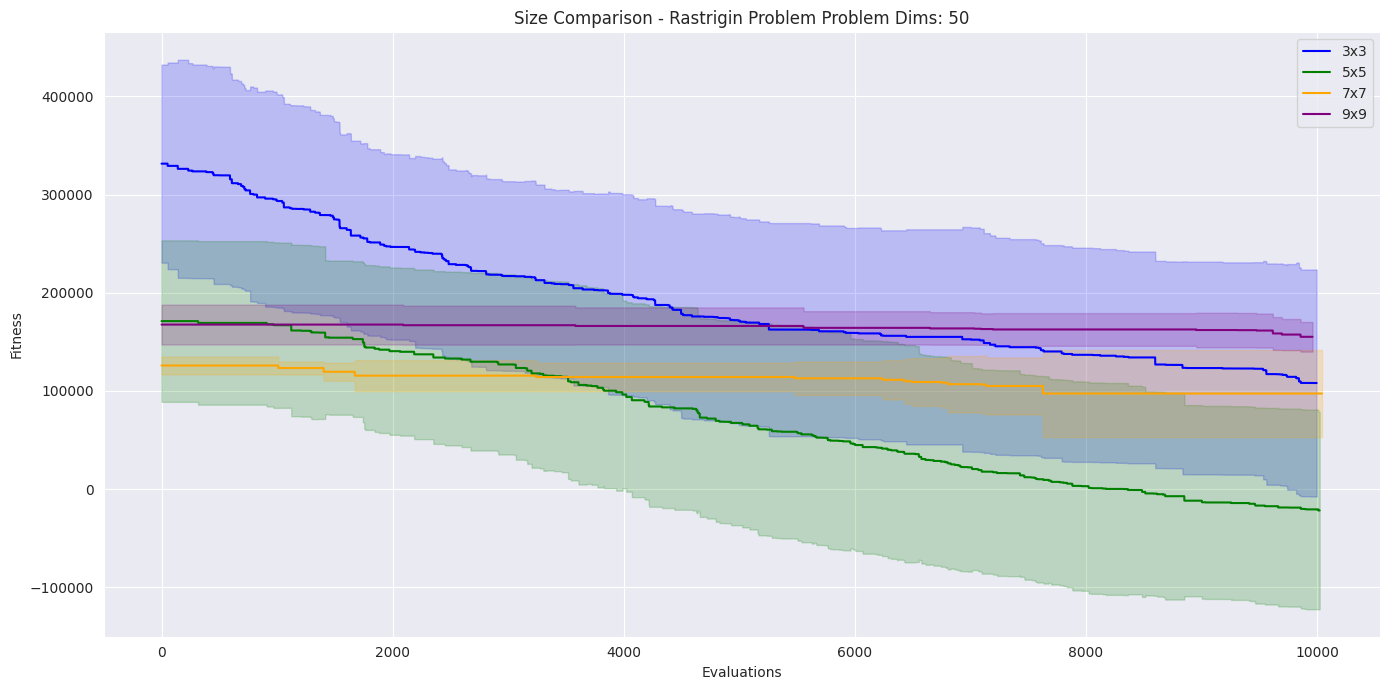

Running size comparison: Rosenbrock Problem


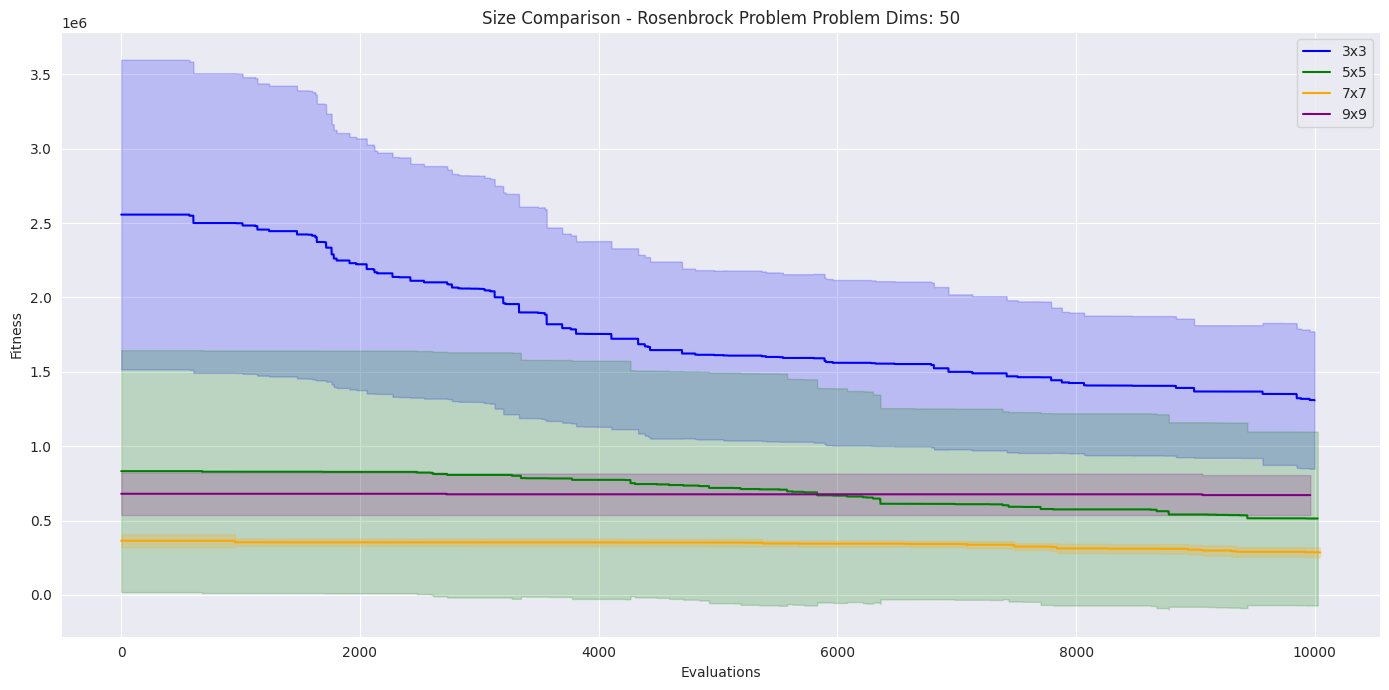

Running size comparison: Ackley Problem


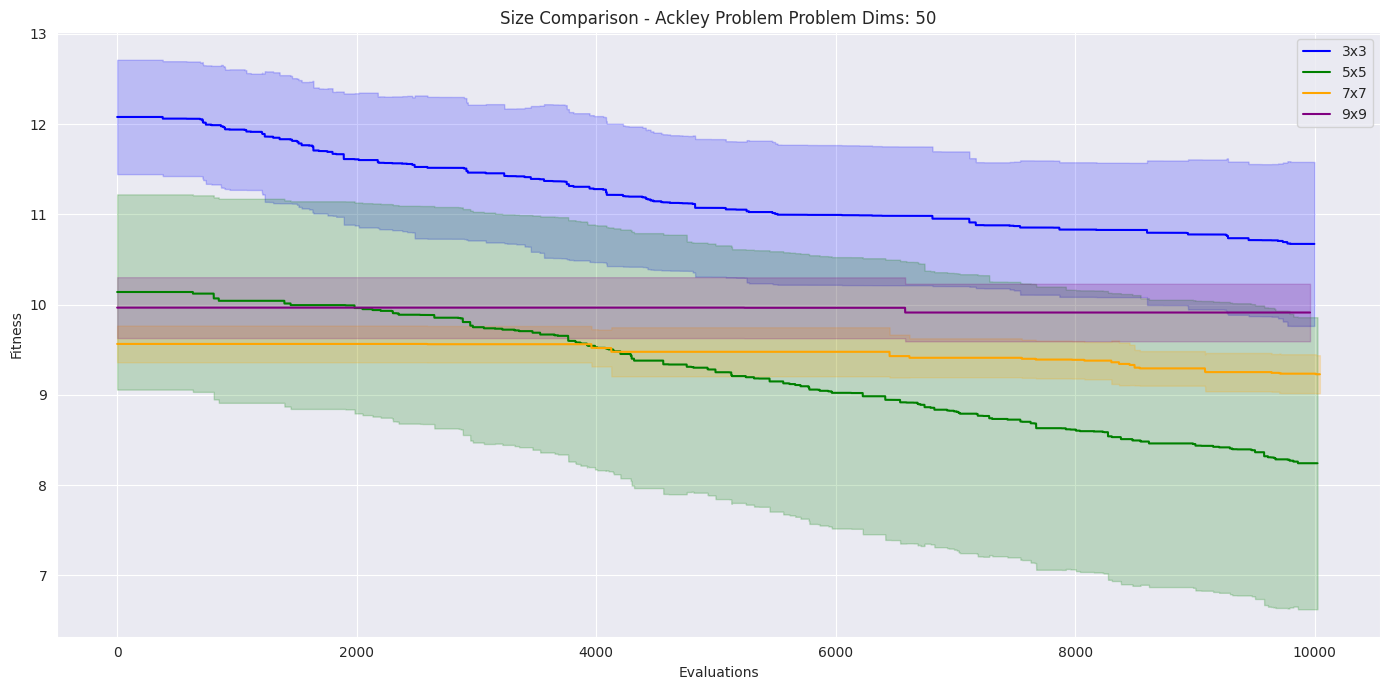

Running size comparison: Griewank Problem


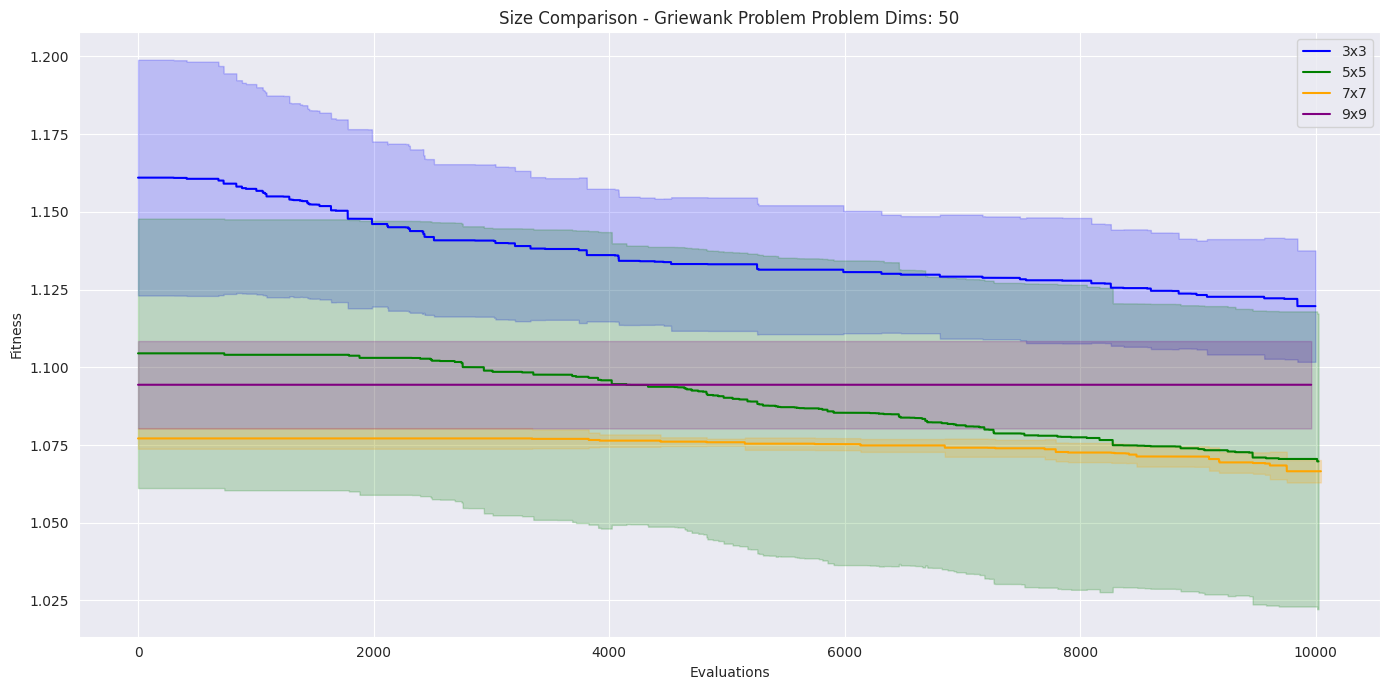

In [9]:
grid_configs = {
    (3, 3):"blue",
    (5, 5):"green",
    (7, 7):"orange",
    (9, 9):"purple"
}


run_size_comparison(problem_classes, grid_configs, graph_type="torus", dims=50, max_evals=10000, repetitions=5, show_std=True)

Running method comparison: Rastrigin Problem


/home/wladek/IdeaProjects/pycellga/venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
2025-06-12 21:35:55,361 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|333/333, best_cost=-1.23e+5
2025-06-12 21:35:55,958 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -123032.30661901085, best pos: [ 0.27903009 -0.48522739  0.39695975  1.13771144 -0.53066783  2.02825666
 -0.52703308  1.48881405  1.34824971  0.42508919  2.3409575   0.44656032
  0.48811498 -0.48477086 -0.34566945  0.3961817   0.60090169  1.35952092
 -0.62368322 -0.53405959  2.51568636  1.58271194 -0.59864942 -1.42177007
 -0.61538082  2.44213112 -0.68633026  0.41429807 -2.54215625 -0.51569269
  1.23290618  2.45068583 -0.50409681  1.50948799 -1.40044441 -0.58359543
 -1.14296861 -0.57244194  0.49507394  0.69032859  0.09176563 

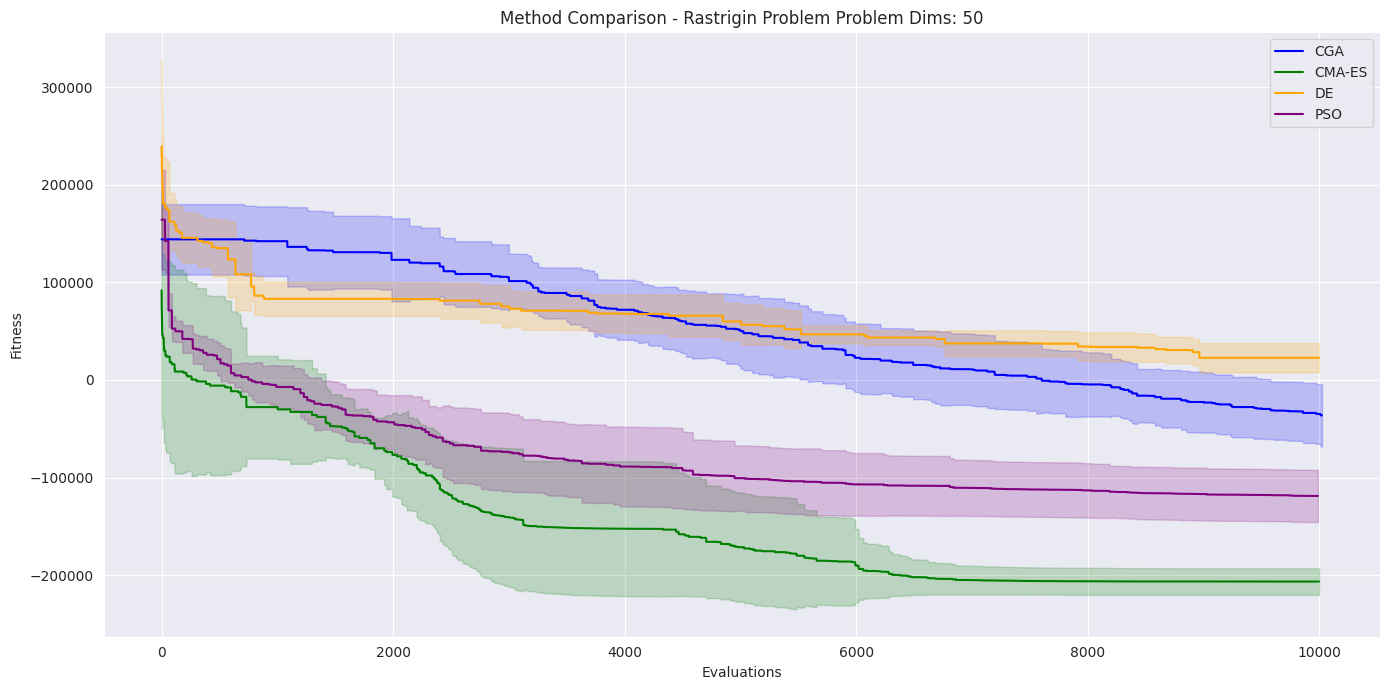

Running method comparison: Rosenbrock Problem


2025-06-12 21:39:49,800 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|333/333, best_cost=1.63e+4
2025-06-12 21:39:53,168 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 16315.71187220508, best pos: [-2.82343386e-01  5.05051402e-01  2.12447719e+00  2.58074634e+00
  2.72122512e+00  9.53947493e-01 -2.30038337e-01  2.86926905e+00
  8.19846766e-01  2.93971509e+00  2.92023336e+00  3.98040388e-01
  1.30991838e+00  1.54586299e+00  1.49828676e+00  6.95372887e-01
  1.79454794e+00  2.09037731e+00  1.09696938e+00  1.02006205e-03
  1.63226029e-01 -8.90496897e-01  2.29870506e+00  9.64483252e-01
  2.86537575e+00  8.77098671e-01  2.05947486e+00  2.51867670e+00
  2.02903558e+00  2.50740587e+00  1.89178936e+00  1.32405360e+00
  1.46986953e+00  1.43363205e+00  2.44393255e+00 -3.44437063e-01
  2.71745639e+00  2.56506728e+00  1.29124051e+00  1.18315764e-01
  2.93038487e+00  1.8151540

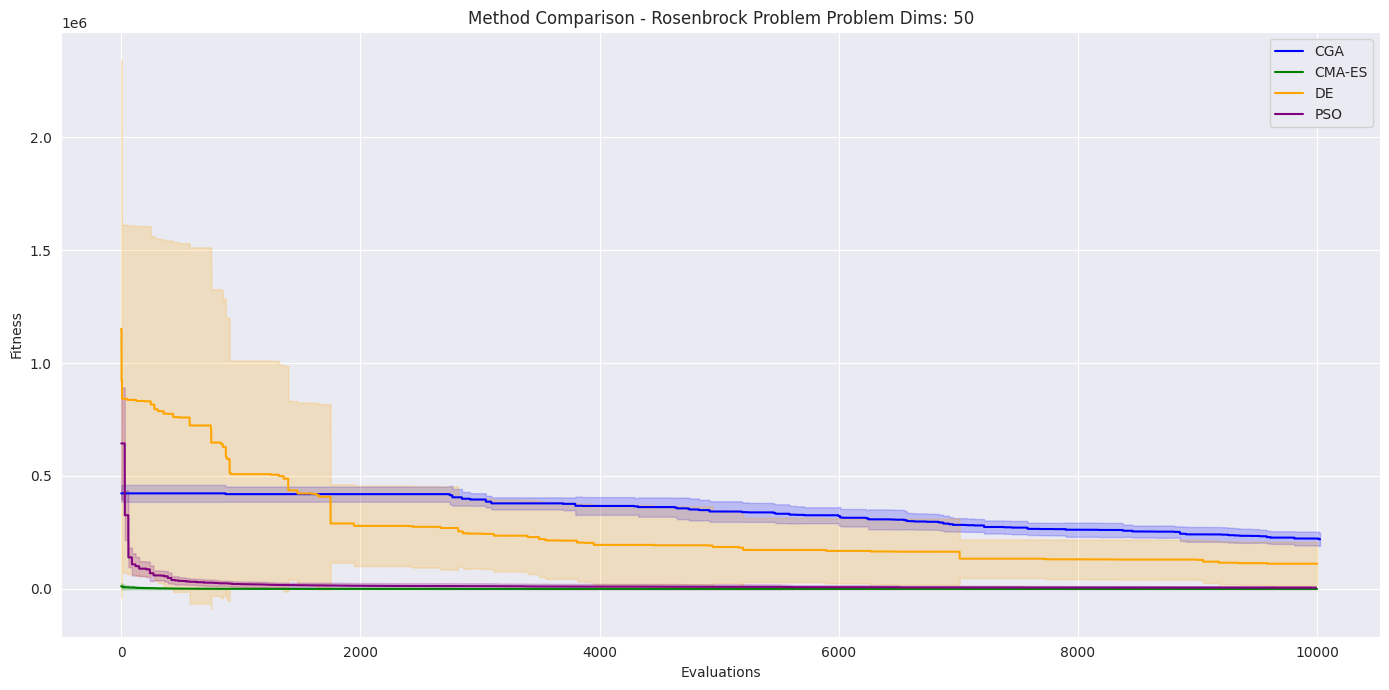

Running method comparison: Ackley Problem


2025-06-12 21:43:30,785 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|333/333, best_cost=2.98
2025-06-12 21:43:32,355 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 2.9818257181946817, best pos: [-0.249681    0.06721268 -0.12164402  0.86563547 -0.10301219  0.81407556
 -0.73420559 -0.16680853  0.80443237 -0.16503414 -1.13046887  0.9494041
 -0.09938115 -0.11039453 -0.12595525 -0.11252336 -0.12910407  0.76861113
  0.95060497 -0.15137512  0.44555985 -0.11426639 -0.11550826 -0.14102623
 -0.36249032 -0.11581327  0.8185077   0.82941269 -0.21505104 -0.13921345
  0.75515533 -0.04718549 -0.9925061  -1.01214615  0.69914184  0.76914342
 -0.09828007 -0.0587065  -0.02328936  0.82993443  0.88937451 -1.66034284
 -0.19085805  0.71089709  0.8412851  -0.13931171 -0.1552725   0.80788523
 -0.11528666  0.83024874]
2025-06-12 21:43:32,361 - pyswarms.single.global_best - INFO - Optimiz

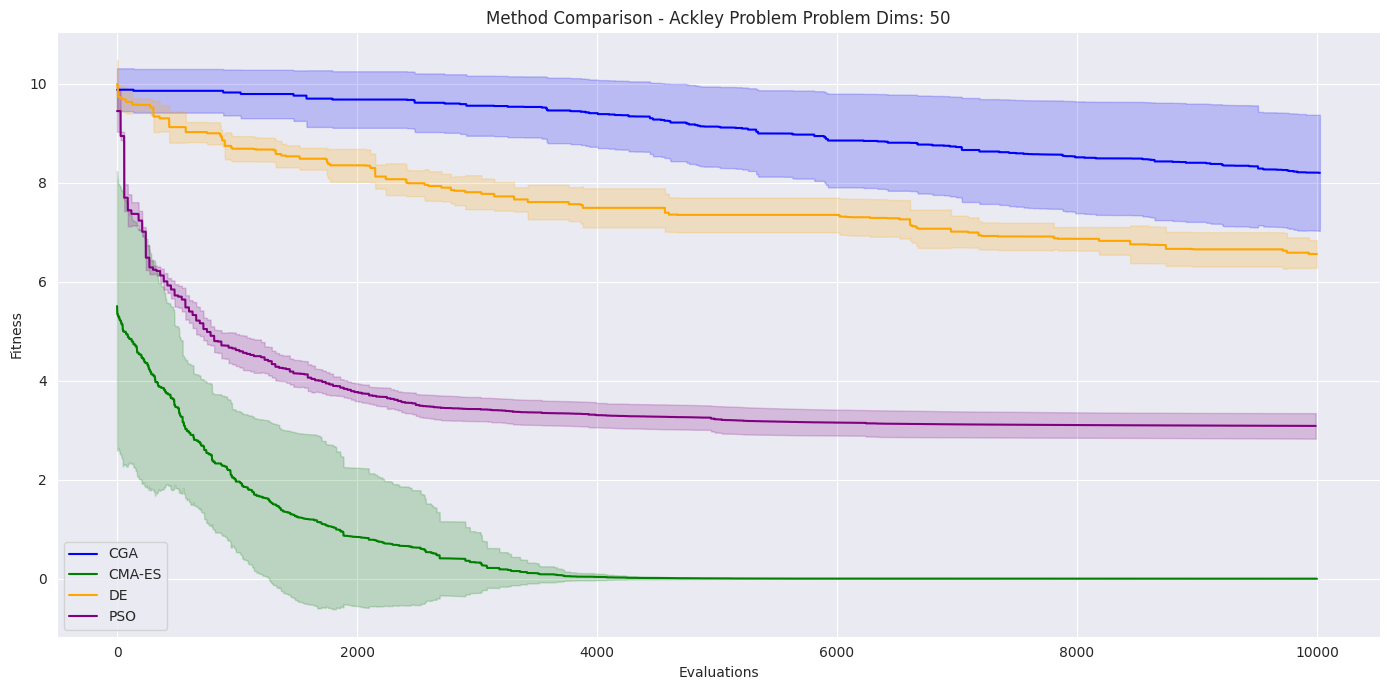

Running method comparison: Griewank Problem


2025-06-12 21:44:05,146 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


Failed for method DE: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.


pyswarms.single.global_best: 100%|██████████|333/333, best_cost=0.732
2025-06-12 21:44:05,894 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.7324859307266025, best pos: [-0.52081873 -0.54186449 -1.00274221 -0.29343945  0.02857627 -0.48306714
 -0.33020512 -0.52702342 -0.24260645 -0.59224028  0.6324906  -0.56081783
 -0.22250963  2.35257302  0.4286094   0.95930064  1.29595333 -0.40957612
 -1.40506214  1.18181633 -2.39838406  0.60955685 -2.04409566 -0.31643794
 -0.51033665 -1.24451195 -0.23824105 -0.44353656 -1.18221311 -0.01891696
  1.13938355  0.4764089  -1.36578779  0.7307449  -1.30078597  0.86552665
 -0.85807981 -1.22115092 -0.48417675 -0.30922724  0.3585117  -0.69887454
  0.86619549 -0.14665774  0.90082354  0.91432711  1.11635338  1.57165227
 -0.83046654 -0.43475575]
2025-06-12 21:44:05,900 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|333/333, best_cost=0.18

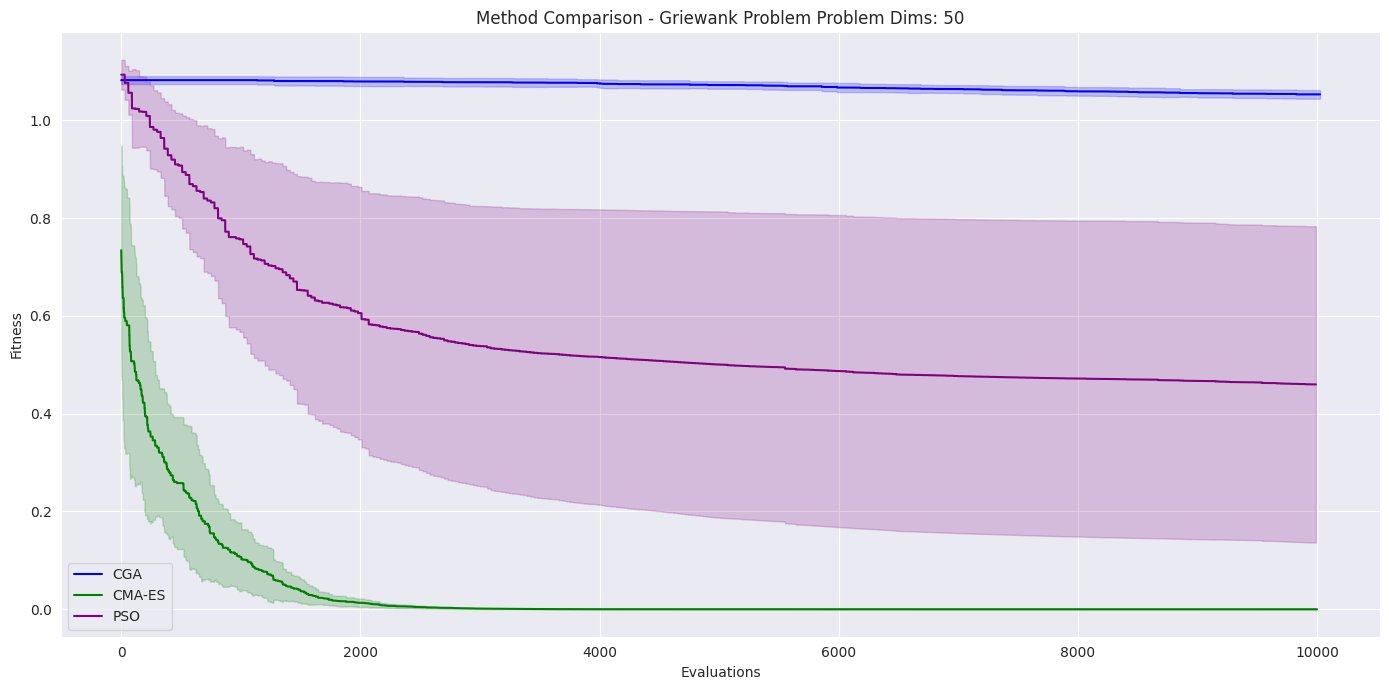

In [10]:
methods = {
    "CGA": (run_cga, "blue"),
    "CMA-ES": (run_cma, "green"),
    "DE": (run_differential_evolution, "orange"),
    "PSO": (run_pso, "purple")
}


run_method_comparison(problem_classes, methods, graph_type="torus", dims=50, max_evals=10000, repetitions=5, show_std=True)

Running graph comparison: Rastrigin Problem


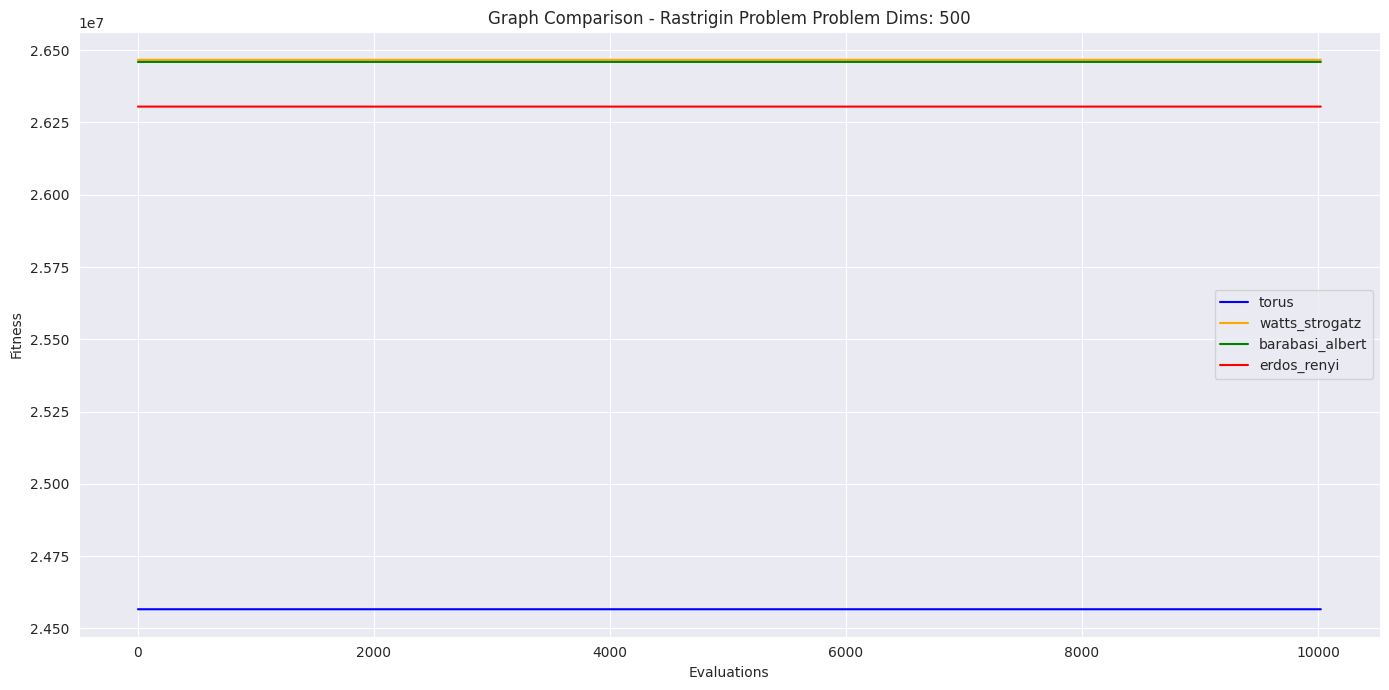

Running graph comparison: Rosenbrock Problem


/home/wladek/IdeaProjects/pycellga/pycellga/GraphProblem.py:61: RuntimeWarning: overflow encountered in scalar subtract
  (100 * np.power((x[i + 1] - np.power(x[i], 2)), 2)) + np.power((1 - x[i]), 2)


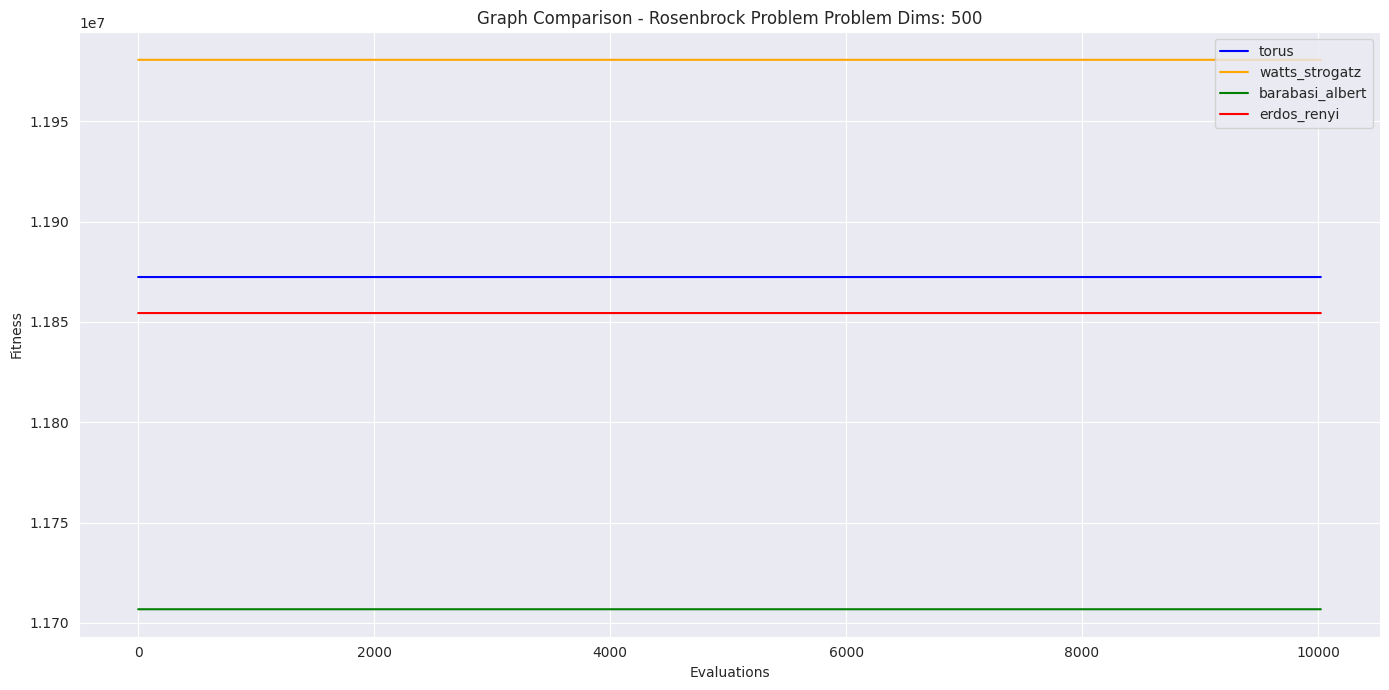

Running graph comparison: Ackley Problem


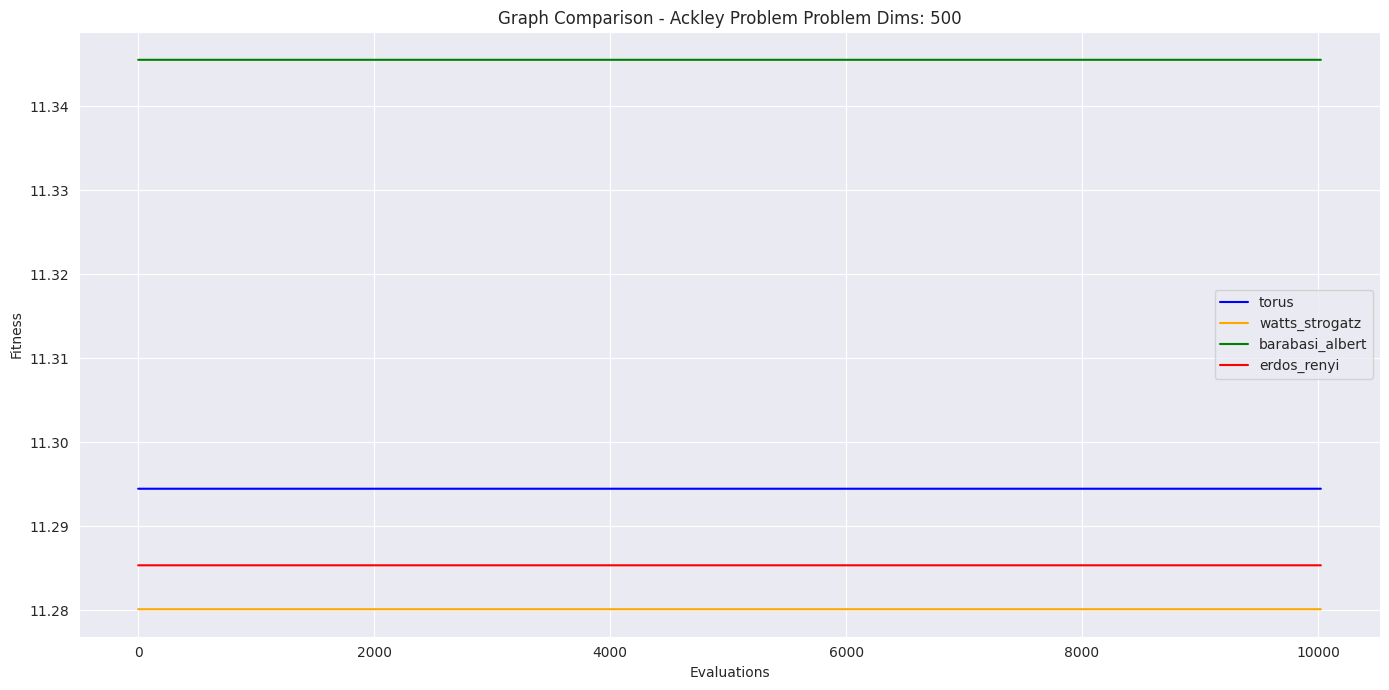

Running graph comparison: Griewank Problem


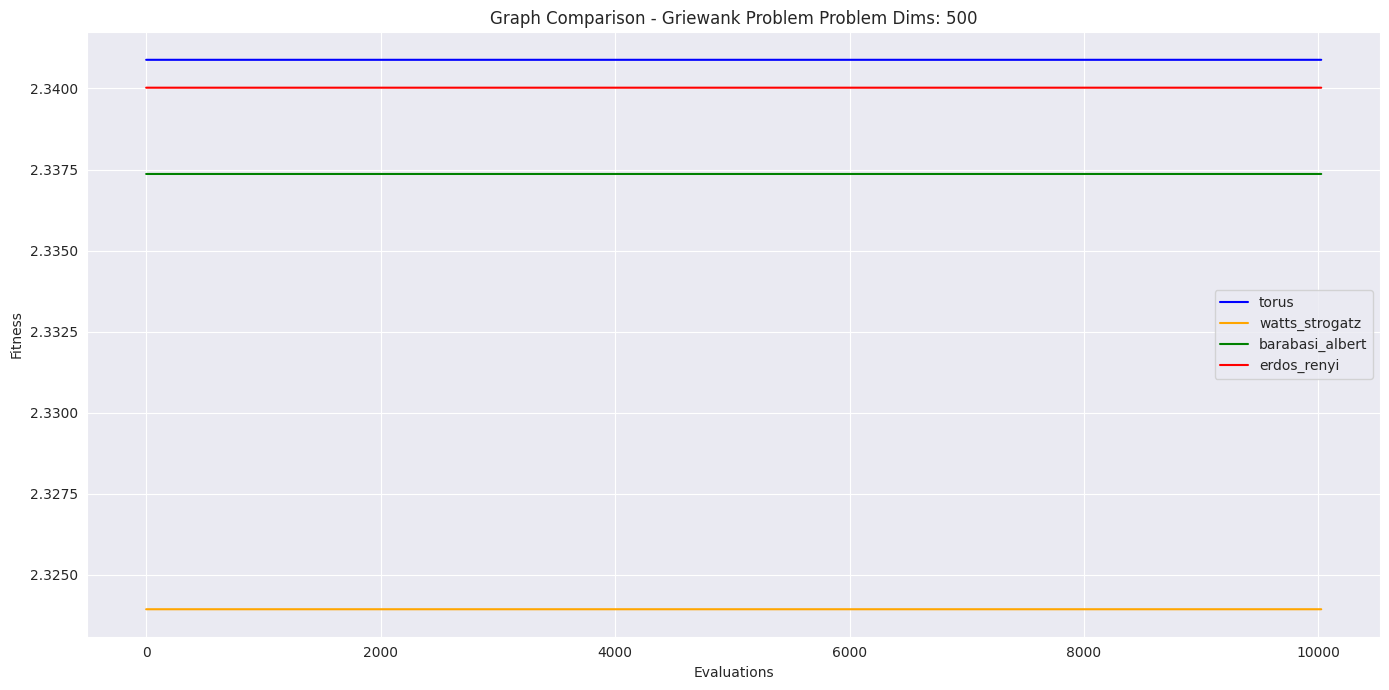

In [11]:
run_graph_comparison(problem_classes, graph_types, graphs_params, dims=500, max_evals=10000, repetitions=5, show_std=False, **config)

Running method comparison: Rastrigin Problem


2025-06-12 22:34:49,008 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=-2.1e+3
2025-06-12 22:34:49,053 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -2102.336389122609, best pos: [2.07354021 1.0951394  2.0761204  2.17128653 1.26407354]
2025-06-12 22:34:49,058 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=-2.12e+3
2025-06-12 22:34:49,098 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -2122.396631476051, best pos: [ 1.11293826  0.11920075 -0.93789654  1.10936794  0.02110312]
2025-06-12 22:34:49,102 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=-1.78e+3
2025-06-12 22:34:49,143 - pyswarms.single.gl

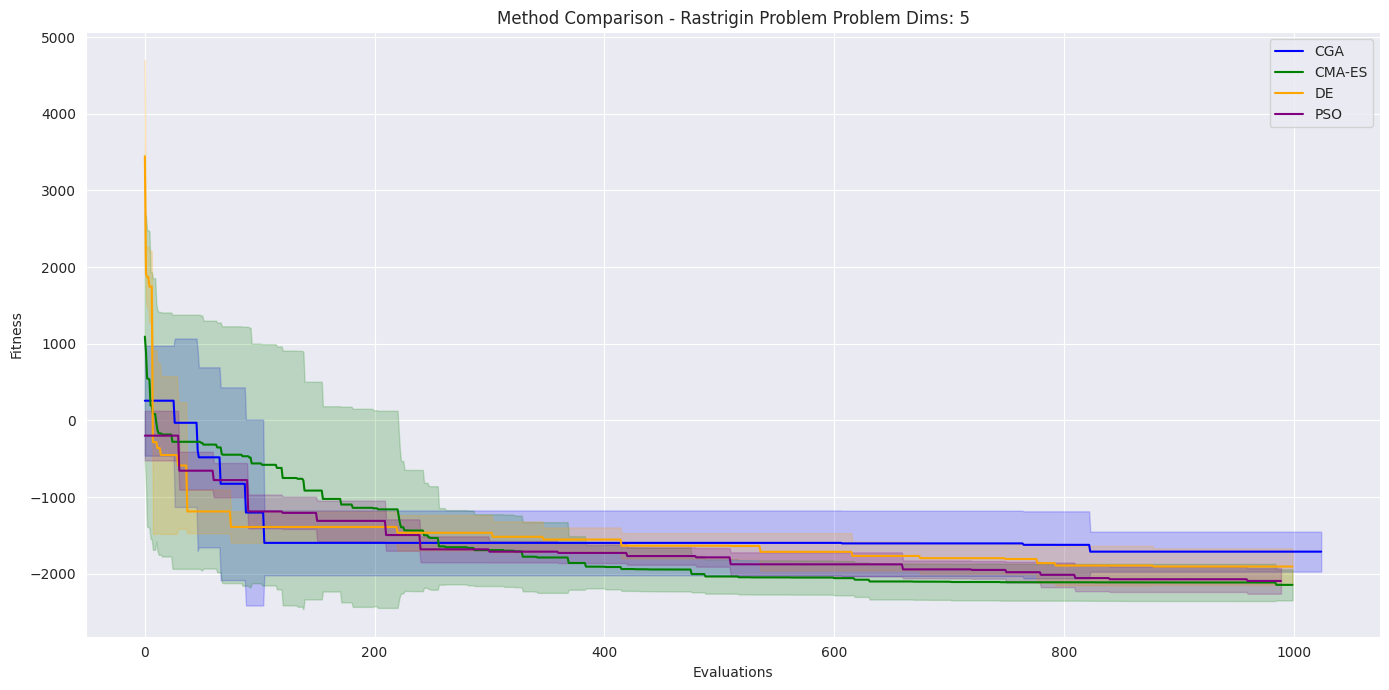

Running method comparison: Rosenbrock Problem


2025-06-12 22:34:52,100 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=1.26
2025-06-12 22:34:52,166 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 1.258385844558636, best pos: [0.88528037 0.77651265 0.60620763 0.38744099 0.14271174]
2025-06-12 22:34:52,171 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=3.93  
2025-06-12 22:34:52,231 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 3.930477227529518, best pos: [0.1057113  0.22021872 0.47545925 1.01703479 3.02662702]
2025-06-12 22:34:52,235 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=5     
2025-06-12 22:34:52,287 - pyswarms.single.global_best - IN

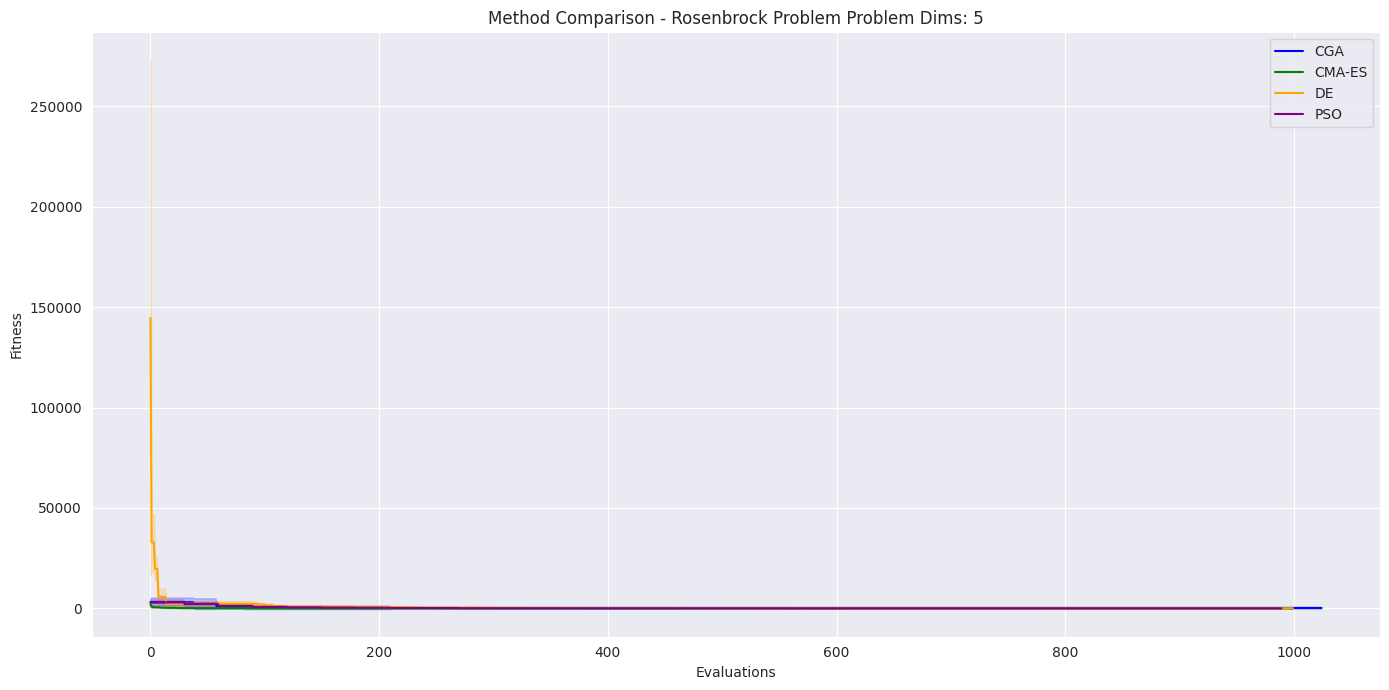

Running method comparison: Ackley Problem


2025-06-12 22:34:55,094 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=0.624
2025-06-12 22:34:55,156 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.6241777110309035, best pos: [-1.90779606 -1.86307447 -1.71225768 -1.82898166 -1.94441339]
2025-06-12 22:34:55,162 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=0.482
2025-06-12 22:34:55,217 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.48175988773440226, best pos: [1.13922153 1.25152915 1.34239531 1.23993175 1.20566983]
2025-06-12 22:34:55,223 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=2.03
2025-06-12 22:34:55,273 - pyswarms.single.global_bes

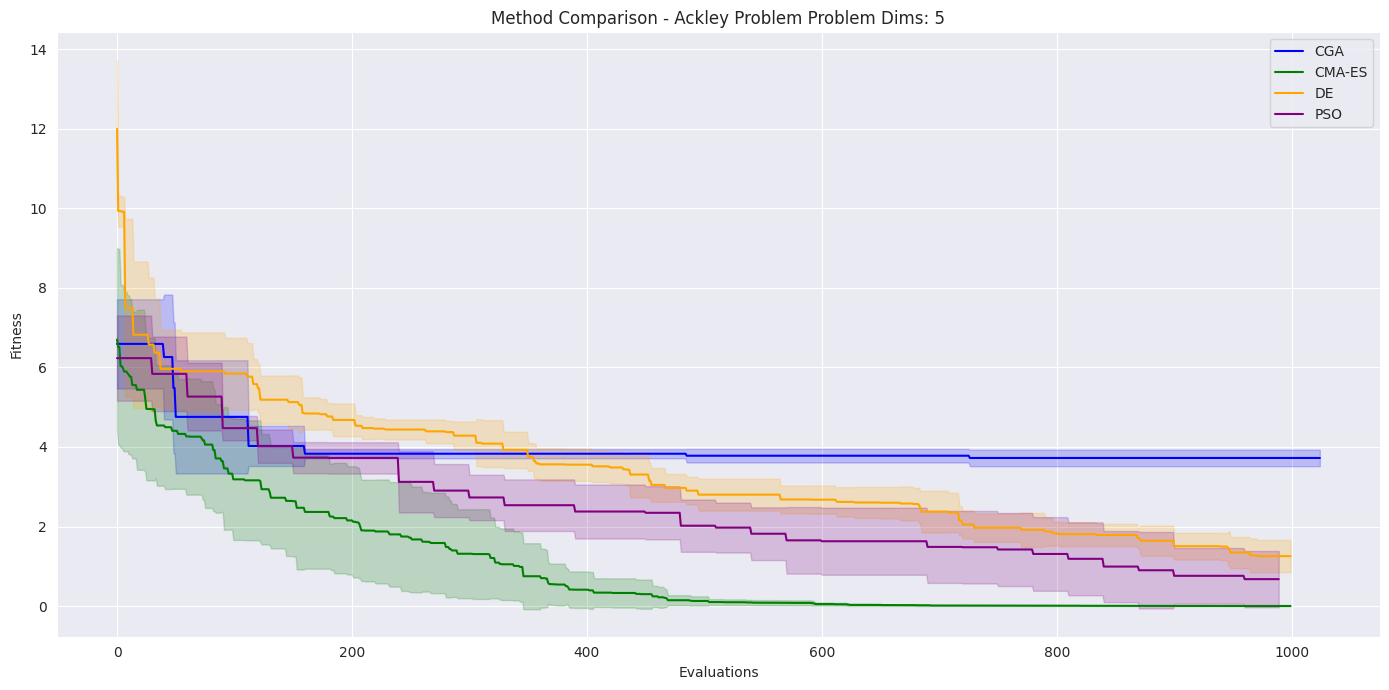

Running method comparison: Griewank Problem


2025-06-12 22:34:57,909 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=0.0369
2025-06-12 22:34:57,949 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.03685666990052461, best pos: [-0.79195307 -3.82178913  1.63888426  2.28706363  3.13385731]
2025-06-12 22:34:57,956 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=0.0446
2025-06-12 22:34:58,003 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.044623570760585096, best pos: [-2.01558019 -2.97952498  1.51866912  1.50978019  1.1710699 ]
2025-06-12 22:34:58,009 - pyswarms.single.global_best - INFO - Optimize for 33 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|33/33, best_cost=0.0185
2025-06-12 22:34:58,059 - pyswarms.single

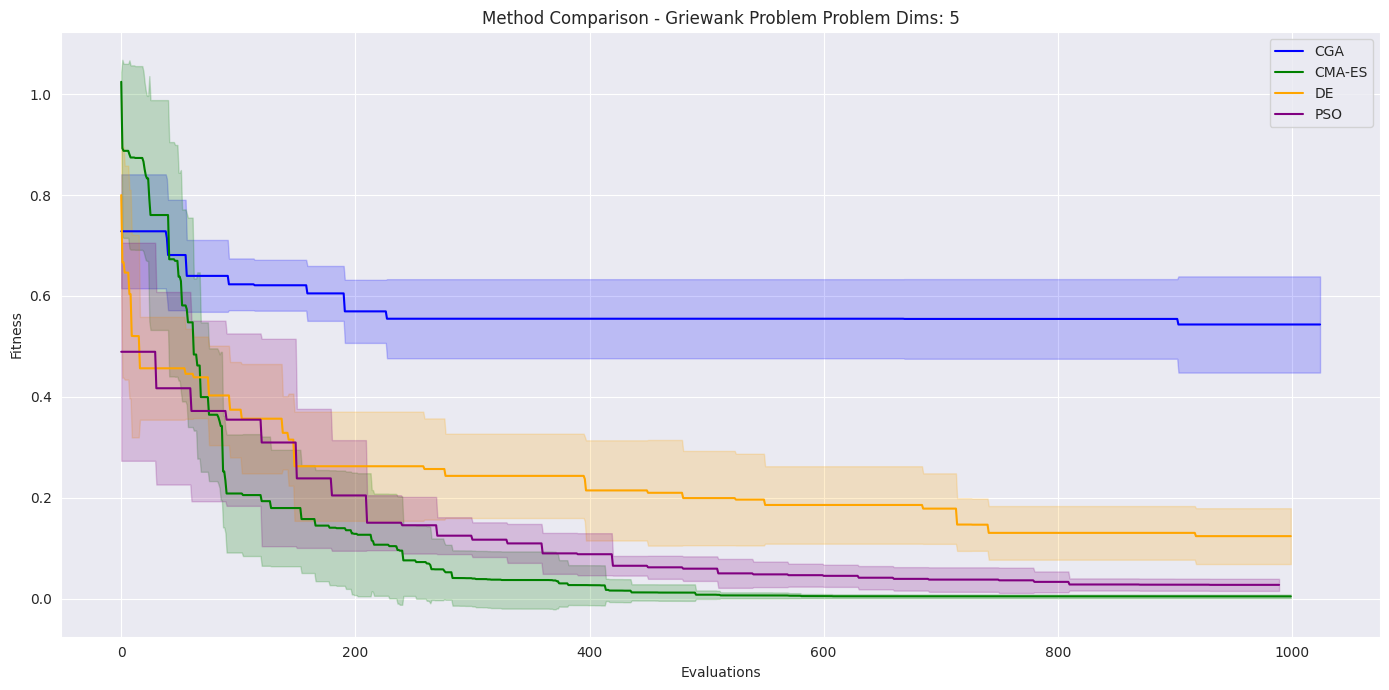

In [12]:
run_method_comparison(problem_classes, methods, graph_type="torus", dims=5, max_evals=1000, repetitions=5, show_std=True)